# 设置基本信息

In [370]:
#设置好字体字号
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)

In [371]:
import pandas as pd

# 1️⃣ 路径赋值
price_path = r"C:\Users\Jerry\Desktop\quant\mid_exam\mid_exam_data\ruc_Class25Q2_train_price.csv"
rent_path = r"C:\Users\Jerry\Desktop\quant\mid_exam\mid_exam_data\ruc_Class25Q2_train_rent.csv"
price_path_test = r"C:\Users\Jerry\Desktop\quant\mid_exam\mid_exam_data\ruc_Class25Q2_test_price.csv"
rent_path_test = r"C:\Users\Jerry\Desktop\quant\mid_exam\mid_exam_data\ruc_Class25Q2_test_rent.csv"

# 2️⃣ 读取数据（ low_memory=False 避免 dtype 警告）
df_price = pd.read_csv(price_path, low_memory=False)
df_rent = pd.read_csv(rent_path, low_memory=False)
df_price_test = pd.read_csv(price_path_test, low_memory=False)
df_rent_test = pd.read_csv(rent_path_test, low_memory=False)


# 对数据查看基本信息

In [372]:
print("📐 数据维度：", df_price.shape)
print("🧩 字段列表：", df_price.columns.tolist())
print("🔍 前几行数据：")
print(df_price.head(3))
print("📊 字段类型与缺失情况：")
df_price.info()

print("📐 数据维度：", df_rent.shape)
print("🧩 字段列表：", df_rent.columns.tolist())
print("🔍 前几行数据：")
print(df_rent.head(3))
print("📊 字段类型与缺失情况：")
df_rent.info()


📐 数据维度： (103871, 55)
🧩 字段列表： ['城市', '区域', '板块', '环线', 'Price', '房屋户型', '所在楼层', '建筑面积', '套内面积', '房屋朝向', '建筑结构', '装修情况', '梯户比例', '配备电梯', '别墅类型', '交易时间', '交易权属', '上次交易', '房屋用途', '房屋年限', '产权所属', '抵押信息', '房屋优势', '核心卖点', '户型介绍', '周边配套', '交通出行', 'lon', 'lat', '年份', '区县', '板块_comm', '环线位置', '物业类别', '建筑年代', '开发商', '房屋总数', '楼栋总数', '物业公司', '绿 化 率', '容 积 率', '物 业 费', '建筑结构_comm', '物业办公电话', '产权描述', '供水', '供暖', '供电', '燃气费', '供热费', '停车位', '停车费用', 'coord_x', 'coord_y', '客户反馈']
🔍 前几行数据：
   城市     区域     板块    环线         Price      房屋户型       所在楼层     建筑面积  \
0   0  109.0  150.0  二至三环  6.194049e+06  2室1厅1厨1卫  中楼层 (共5层)    52.3㎡   
1   0   65.0  299.0  五至六环  4.354153e+06  3室1厅1厨1卫   顶层 (共6层)  127.44㎡   
2   0   62.0  911.0  五至六环  3.321992e+06  3室2厅1厨2卫  低楼层 (共6层)  118.02㎡   

      套内面积 房屋朝向  ...     供水        供暖     供电       燃气费    供热费     停车位 停车费用  \
0      NaN  南 北  ...     民水      集中供暖     民电  2.61元/m³  30元/㎡   300.0   暂无   
1   123.7㎡  南 北  ...  商水/民水       自采暖  商电/民电  2.61元/m³    NaN  1550.0  150  

In [373]:
def missing_summary(df, name='数据集'):
    print(f"\n📉 缺失值分析：{name}")
    
    # 缺失数量和比例
    missing_count = df.isnull().sum()
    missing_ratio = (missing_count / df.shape[0]).round(4)
    
    # 构建表格并格式化百分比
    missing_df = pd.DataFrame({
        '字段名': missing_count.index,
        '缺失数量': missing_count.values,
        '缺失比例': missing_ratio.map(lambda x: f"{x:.2%}")
    })
    
    # 按比例降序排列
    missing_df = missing_df[missing_count >=0].sort_values(by='缺失数量', ascending=False).reset_index(drop=True)
    display(missing_df)

missing_summary(df_price, name='Price 数据集')
missing_summary(df_price_test, name='Price_test 数据集')
missing_summary(df_rent, name='Rent 数据集')
missing_summary(df_rent_test, name='Rent_test 数据集')


📉 缺失值分析：Price 数据集


,字段名,缺失数量,缺失比例
0,抵押信息,103871,100.00%
1,别墅类型,102428,98.61%
2,环线位置,75774,72.95%
3,户型介绍,75100,72.30%
4,供暖,72926,70.21%
5,供热费,72488,69.79%
6,物业办公电话,68935,66.37%
7,套内面积,67887,65.36%
8,环线,63452,61.09%
9,房屋年限,44510,42.85%



📉 缺失值分析：Price_test 数据集


,字段名,缺失数量,缺失比例
0,抵押信息,34017,100.00%
1,别墅类型,33863,99.55%
2,套内面积,24102,70.85%
3,户型介绍,24005,70.57%
4,供热费,23028,67.70%
5,物业办公电话,22593,66.42%
6,环线位置,20644,60.69%
7,供暖,18602,54.68%
8,环线,18340,53.91%
9,交通出行,15358,45.15%



📉 缺失值分析：Rent 数据集


,字段名,缺失数量,缺失比例
0,车位,74135,74.96%
1,装修,73489,74.31%
2,供热费,70064,70.84%
3,环线位置,69663,70.44%
4,采暖,64487,65.20%
5,供暖,61204,61.89%
6,物业办公电话,60692,61.37%
7,租期,46933,47.46%
8,配套设施,30451,30.79%
9,物业公司,28753,29.07%



📉 缺失值分析：Rent_test 数据集


,字段名,缺失数量,缺失比例
0,车位,7611,77.88%
1,供热费,7054,72.18%
2,环线位置,6962,71.24%
3,采暖,6560,67.12%
4,物业办公电话,6453,66.03%
5,供暖,6195,63.39%
6,租期,5175,52.95%
7,配套设施,3694,37.80%
8,物业公司,3479,35.60%
9,建筑年代,3381,34.60%


d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


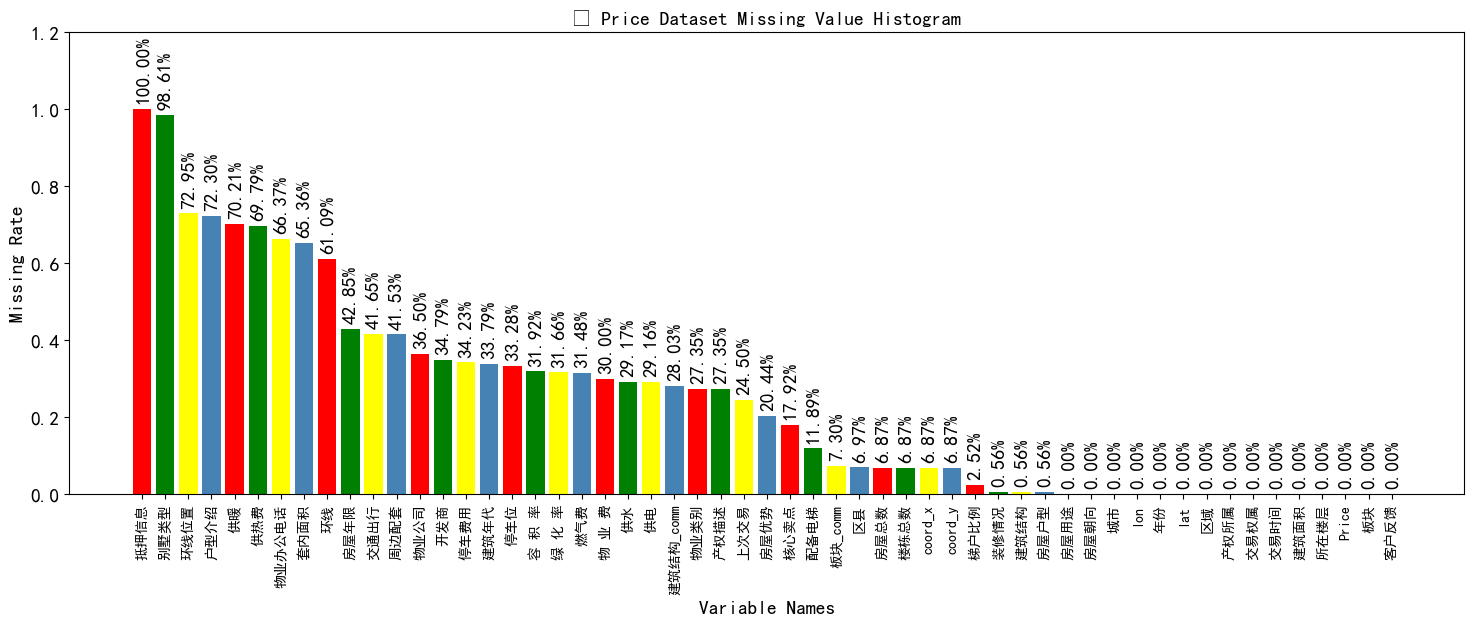

d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


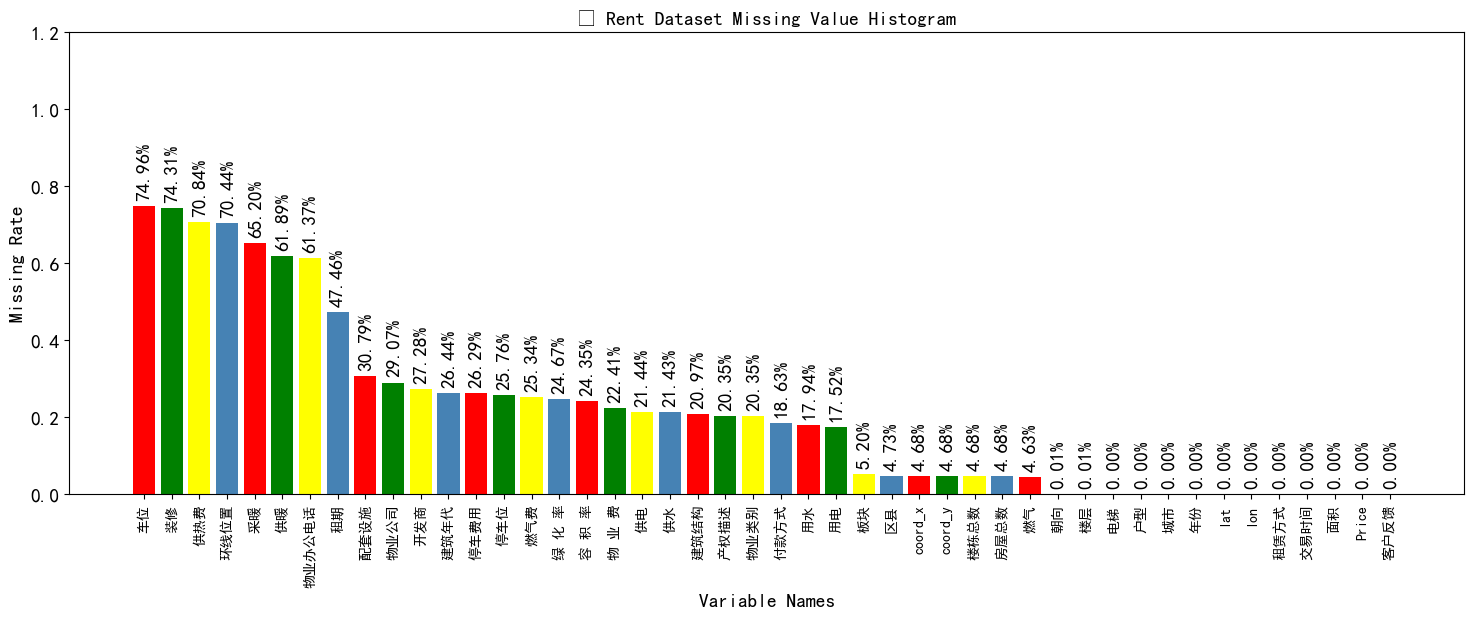

In [374]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl

def plot_missing(data, title='Missing Value Histogram'):
    # 统计缺失值数量
    missing = data.isnull().sum().reset_index().rename(columns={0: 'missNum', 'index': 'variable'})
    # 计算缺失比例
    missing['missRate'] = missing['missNum'] / data.shape[0]
    # 按照缺失率排序显示
    miss_analy = missing[missing.missRate >=0].sort_values(by='missRate', ascending=False)

    # 绘图
    fig = plt.figure(figsize=(18, 6))
    plt.bar(np.arange(miss_analy.shape[0]), miss_analy['missRate'], align='center',
            color=['red', 'green', 'yellow', 'steelblue'])
    plt.title(title)
    plt.xlabel('Variable Names')
    plt.ylabel('Missing Rate')
    plt.xticks(np.arange(miss_analy.shape[0]), miss_analy['variable'])
    pl.xticks(rotation=90)

    # 添加数值显示
    for x, y in enumerate(miss_analy['missRate']):
        plt.text(x, y + 0.02, '{:.2%}'.format(y), ha='center', rotation=90)

    plt.ylim([0, 1.2])
    plt.show()

# 应用到两个数据集
plot_missing(df_price, title='📉 Price Dataset Missing Value Histogram')
plot_missing(df_rent, title='📉 Rent Dataset Missing Value Histogram')


进行数据清洗

In [375]:
# 创建数据副本用于清洗
print("创建数据副本...")
df_price_clean = df_price.copy() 
df_rent_clean = df_rent.copy()  
print("📐 数据维度：", df_price_clean.shape)
print("📐 数据维度：", df_rent_clean.shape)

创建数据副本...
📐 数据维度： (103871, 55)
📐 数据维度： (98899, 46)


In [376]:
# 显示被删除的列及其缺失率
def show_dropped_columns(df, columns_to_drop, dataset_name):
    if len(columns_to_drop) > 0:
        missing_rates = (df[columns_to_drop].isnull().mean() * 100).round(2)
        print(f"\n🗑️ {dataset_name}中删除的列（缺失率 > 50%）：")
        for col, rate in missing_rates.items():
            print(f"- {col}: {rate}% 缺失")
    else:
        print(f"\n✅ {dataset_name}中没有列的缺失率超过50%")

print("\n=== 删除缺失率过高的列 ===")

columns_to_drop_price = df_price_clean.columns[df_price_clean.isnull().mean() > 0.5]
columns_to_drop_rent = df_rent_clean.columns[df_rent_clean.isnull().mean() > 0.5]

show_dropped_columns(df_price_clean, columns_to_drop_price, "房价数据集")
show_dropped_columns(df_rent_clean, columns_to_drop_rent, "租金数据集")

# 删除缺失率超过50%的列
df_price_clean = df_price_clean.drop(columns=columns_to_drop_price)
df_rent_clean = df_rent_clean.drop(columns=columns_to_drop_rent)

#对于test数据做同样处理
df_price_test=df_price_test.drop(columns=columns_to_drop_price)
df_rent_test=df_rent_test.drop(columns=columns_to_drop_rent)

# 显示删除前后的维度变化
print("\n📊 数据维度变化：")
print(f"房价数据集：{df_price.shape[1]} 列 -> {df_price_clean.shape[1]} 列")
print(f"租金数据集：{df_rent.shape[1]} 列 -> {df_rent_clean.shape[1]} 列")
print(f"房价测试数据集：{df_price_test.shape[1]+len(columns_to_drop_price)} 列 -> {df_price_test.shape[1]} 列")
print(f"租金测试数据集：{df_rent_test.shape[1]+len(columns_to_drop_rent)} 列 -> {df_rent_test.shape[1]} 列")





=== 删除缺失率过高的列 ===

🗑️ 房价数据集中删除的列（缺失率 > 50%）：
- 环线: 61.09% 缺失
- 套内面积: 65.36% 缺失
- 别墅类型: 98.61% 缺失
- 抵押信息: 100.0% 缺失
- 户型介绍: 72.3% 缺失
- 环线位置: 72.95% 缺失
- 物业办公电话: 66.37% 缺失
- 供暖: 70.21% 缺失
- 供热费: 69.79% 缺失

🗑️ 租金数据集中删除的列（缺失率 > 50%）：
- 装修: 74.31% 缺失
- 车位: 74.96% 缺失
- 采暖: 65.2% 缺失
- 环线位置: 70.44% 缺失
- 物业办公电话: 61.37% 缺失
- 供暖: 61.89% 缺失
- 供热费: 70.84% 缺失

📊 数据维度变化：
房价数据集：55 列 -> 46 列
租金数据集：46 列 -> 39 列
房价测试数据集：55 列 -> 46 列
租金测试数据集：46 列 -> 39 列


# 清洗后数据集的详细信息

In [377]:
# 定义一个函数来显示数据集的详细信息
def show_dataset_info(df, dataset_name):
    print(f"\n=== {dataset_name}数据集信息 ===")
    print("=" * 50)
    
    # 1. 数据维度
    print(f"\n📊 数据维度：{df.shape}")
    
    # 2. 列信息：名称、类型和缺失比例
    print("\n📋 列信息统计：")
    print("-" * 50)
    info_df = pd.DataFrame({
        '数据类型': df.dtypes,
        '非空值数量': df.count(),
        '缺失值数量': df.isnull().sum(),
        '缺失比例': (df.isnull().sum() / len(df) * 100).round(2).astype(str) + '%'
    })
    print(info_df)
    
    # 3. 数值型列的基本统计
    print("\n📈 数值型列的基本统计：")
    print("-" * 50)
    numeric_cols = df.select_dtypes(include=['int64', 'float64'])
    print(numeric_cols.describe().round(2))

print("\n清洗后的数据集信息：")
print("=" * 50)

# 显示两个清洗后的数据集信息
show_dataset_info(df_price_clean, "房价")
show_dataset_info(df_rent_clean, "租金")


清洗后的数据集信息：

=== 房价数据集信息 ===

📊 数据维度：(103871, 46)

📋 列信息统计：
--------------------------------------------------
              数据类型   非空值数量  缺失值数量    缺失比例
城市           int64  103871      0    0.0%
区域         float64  103871      0    0.0%
板块         float64  103871      0    0.0%
Price      float64  103871      0    0.0%
房屋户型        object  103291    580   0.56%
所在楼层        object  103871      0    0.0%
建筑面积        object  103871      0    0.0%
房屋朝向        object  103870      1    0.0%
建筑结构        object  103291    580   0.56%
装修情况        object  103291    580   0.56%
梯户比例        object  101252   2619   2.52%
配备电梯        object   91520  12351  11.89%
交易时间        object  103871      0    0.0%
交易权属        object  103871      0    0.0%
上次交易        object   78422  25449   24.5%
房屋用途        object  103870      1    0.0%
房屋年限        object   59361  44510  42.85%
产权所属        object  103871      0    0.0%
房屋优势        object   82635  21236  20.44%
核心卖点        object   85257  18614  17.92%
周边配套   

In [378]:
# 查看非数值类型列的示例值
def analyze_non_numeric_columns(df, dataset_name):
    # 获取非数值类型的列
    non_numeric_cols = df.select_dtypes(exclude=['int64', 'float64']).columns
    
    print(f"\n=== {dataset_name}非数值类型列分析 ===")
    print("=" * 50)
    
    for col in non_numeric_cols:
        print(f"\n📝 列名：{col}")
        print(f"数据类型：{df[col].dtype}")
        print("唯一值示例（前5个）：")
        unique_values = df[col].dropna().unique()[:5]
        for idx, val in enumerate(unique_values, 1):
            print(f"{idx}. {val}")
        print(f"总共有 {len(df[col].unique())} 个唯一值")
        print("-" * 30)

print("分析房价数据集的非数值列：")
analyze_non_numeric_columns(df_price_clean, "房价数据集")

print("\n分析租金数据集的非数值列：")
analyze_non_numeric_columns(df_rent_clean, "租金数据集")

分析房价数据集的非数值列：

=== 房价数据集非数值类型列分析 ===

📝 列名：房屋户型
数据类型：object
唯一值示例（前5个）：
1. 2室1厅1厨1卫
2. 3室1厅1厨1卫
3. 3室2厅1厨2卫
4. 6室3厅1厨3卫
5. 1房间1卫
总共有 389 个唯一值
------------------------------

📝 列名：所在楼层
数据类型：object
唯一值示例（前5个）：
1. 中楼层 (共5层)
2. 顶层 (共6层)
3. 低楼层 (共6层)
4. 底层 (共2层)
5. 中楼层 (共10层)
总共有 258 个唯一值
------------------------------

📝 列名：建筑面积
数据类型：object
唯一值示例（前5个）：
1. 52.3㎡
2. 127.44㎡
3. 118.02㎡
4. 293.23㎡
5. 39.85㎡
总共有 15772 个唯一值
------------------------------

📝 列名：房屋朝向
数据类型：object
唯一值示例（前5个）：
1. 南 北
2. 东南
3. 东 南 西 北
4. 南
5. 南 西 北
总共有 174 个唯一值
------------------------------

📝 列名：建筑结构
数据类型：object
唯一值示例（前5个）：
1. 混合结构
2. 钢混结构
3. 砖混结构
4. 钢结构
5. 砖木结构
总共有 8 个唯一值
------------------------------

📝 列名：装修情况
数据类型：object
唯一值示例（前5个）：
1. 精装
2. 简装
3. 毛坯
4. 其他
总共有 5 个唯一值
------------------------------

📝 列名：梯户比例
数据类型：object
唯一值示例（前5个）：
1. 一梯三户
2. 一梯两户
3. 一梯五户
4. 两梯十一户
5. 一梯六户
总共有 328 个唯一值
------------------------------

📝 列名：配备电梯
数据类型：object
唯一值示例（前5个）：
1. 无
2. 有
总共有 3 个唯一值
------------------------------

📝 列名：交易时间

# 删除所有无关列，删除重复列，删除无意义的列

In [379]:
# 删除房价数据集指定列
columns_to_drop = ['客户反馈','物业公司','楼栋总数','停车位','停车费用','周边配套','交通出行', '房屋总数', '板块_comm', '区县', '核心卖点', '开发商','coord_x', 'coord_y']
print("准备删除以下列：", columns_to_drop)

# 检查这些列是否存在于数据集中
existing_columns = [col for col in columns_to_drop if col in df_price_clean.columns]
if len(existing_columns) > 0:
    print(f"\n找到 {len(existing_columns)} 个要删除的列：")
    print(existing_columns)
    # 删除这些列
    df_price_clean = df_price_clean.drop(columns=existing_columns)
    df_price_test = df_price_test.drop(columns=columns_to_drop)
    print(f"\n删除完成。当前数据集维度：{df_price_clean.shape}")
else:
    print("未找到需要删除的列")

    # 显示当前所有列名
print("\n当前数据集中的所有列名：")
print("=" * 50)
for col in df_price_clean.columns:
    print(f"- {col}")

# 保存更新后的数据集
df_price_clean.to_csv("cleaned_price.csv", index=False)
print("\n更新后的数据已保存到 cleaned_price.csv")

df_price_test.to_csv("cleaned_price_test.csv", index=False)
print("\n更新后的测试数据已保存到 cleaned_price_test.csv")


准备删除以下列： ['客户反馈', '物业公司', '楼栋总数', '停车位', '停车费用', '周边配套', '交通出行', '房屋总数', '板块_comm', '区县', '核心卖点', '开发商', 'coord_x', 'coord_y']

找到 14 个要删除的列：
['客户反馈', '物业公司', '楼栋总数', '停车位', '停车费用', '周边配套', '交通出行', '房屋总数', '板块_comm', '区县', '核心卖点', '开发商', 'coord_x', 'coord_y']

删除完成。当前数据集维度：(103871, 32)

当前数据集中的所有列名：
- 城市
- 区域
- 板块
- Price
- 房屋户型
- 所在楼层
- 建筑面积
- 房屋朝向
- 建筑结构
- 装修情况
- 梯户比例
- 配备电梯
- 交易时间
- 交易权属
- 上次交易
- 房屋用途
- 房屋年限
- 产权所属
- 房屋优势
- lon
- lat
- 年份
- 物业类别
- 建筑年代
- 绿 化 率
- 容 积 率
- 物 业 费
- 建筑结构_comm
- 产权描述
- 供水
- 供电
- 燃气费

更新后的数据已保存到 cleaned_price.csv

更新后的测试数据已保存到 cleaned_price_test.csv


In [380]:
# 删除租金数据集中的指定列
rent_columns_to_drop = ['客户反馈', '物业公司', '房屋总数', '楼栋总数', '开发商', 'coord_x', 'coord_y','朝向','交易时间','付款方式',
'租期','年份','区县','板块','物业类别','建筑年代','停车位','停车费用','建筑结构']
print("准备从租金数据集中删除以下列：", rent_columns_to_drop)

# 检查这些列是否存在于数据集中
existing_columns = [col for col in rent_columns_to_drop if col in df_rent_clean.columns]
if len(existing_columns) > 0:
    print(f"\n找到 {len(existing_columns)} 个要删除的列：")
    print(existing_columns)
    # 删除这些列
    df_rent_clean = df_rent_clean.drop(columns=existing_columns)
    df_rent_test = df_rent_test.drop(columns=rent_columns_to_drop)
    print(f"\n删除完成。当前数据集维度：{df_rent_clean.shape}")
else:
    print("未找到需要删除的列")

# 显示当前所有列名
print("\n当前租金数据集中的所有列名：")
print("=" * 50)
for col in df_rent_clean.columns:
    print(f"- {col}")

# 保存更新后的数据集
df_rent_clean.to_csv("cleaned_rent.csv", index=False)
print("\n更新后的数据已保存到 cleaned_rent.csv")

df_rent_test.to_csv("cleaned_rent_test.csv", index=False)
print("\n更新后的测试数据已保存到 cleaned_rent_test.csv")



准备从租金数据集中删除以下列： ['客户反馈', '物业公司', '房屋总数', '楼栋总数', '开发商', 'coord_x', 'coord_y', '朝向', '交易时间', '付款方式', '租期', '年份', '区县', '板块', '物业类别', '建筑年代', '停车位', '停车费用', '建筑结构']

找到 19 个要删除的列：
['客户反馈', '物业公司', '房屋总数', '楼栋总数', '开发商', 'coord_x', 'coord_y', '朝向', '交易时间', '付款方式', '租期', '年份', '区县', '板块', '物业类别', '建筑年代', '停车位', '停车费用', '建筑结构']

删除完成。当前数据集维度：(98899, 20)

当前租金数据集中的所有列名：
- 城市
- 户型
- Price
- 楼层
- 面积
- 租赁方式
- 电梯
- 用水
- 用电
- 燃气
- 配套设施
- lon
- lat
- 绿 化 率
- 容 积 率
- 物 业 费
- 产权描述
- 供水
- 供电
- 燃气费

更新后的数据已保存到 cleaned_rent.csv

更新后的测试数据已保存到 cleaned_rent_test.csv


d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


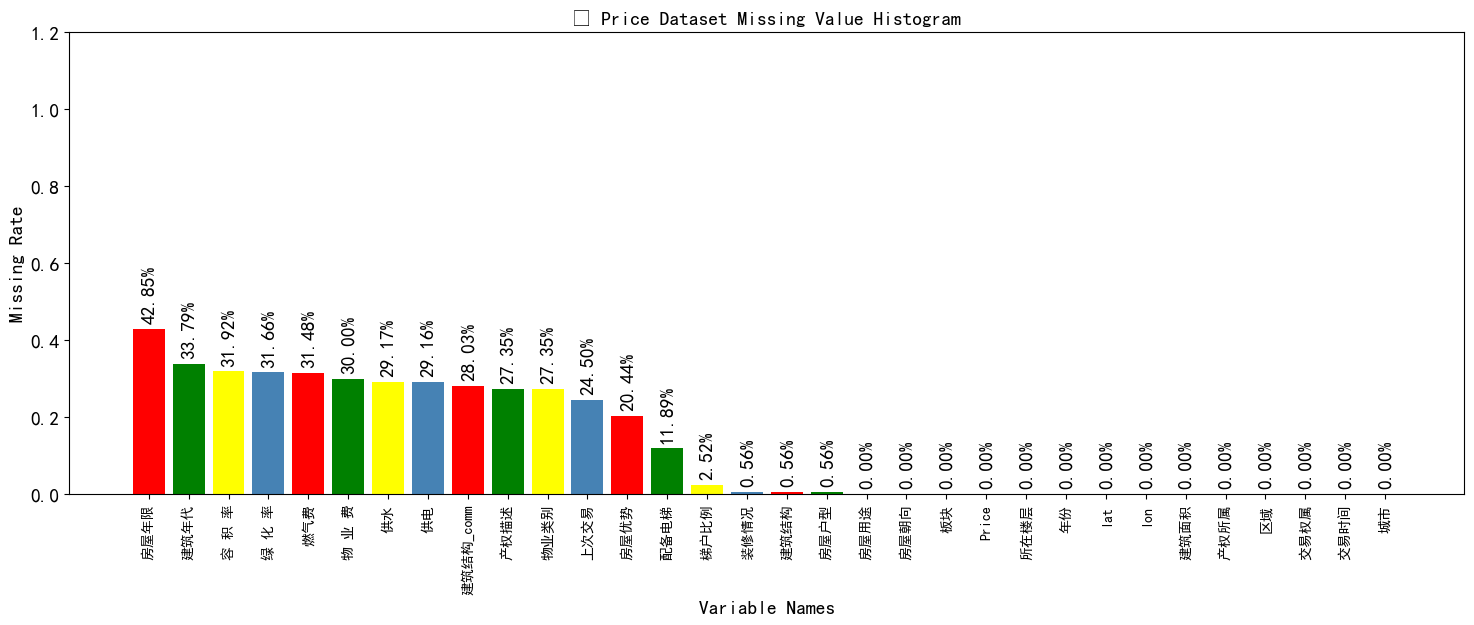

d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


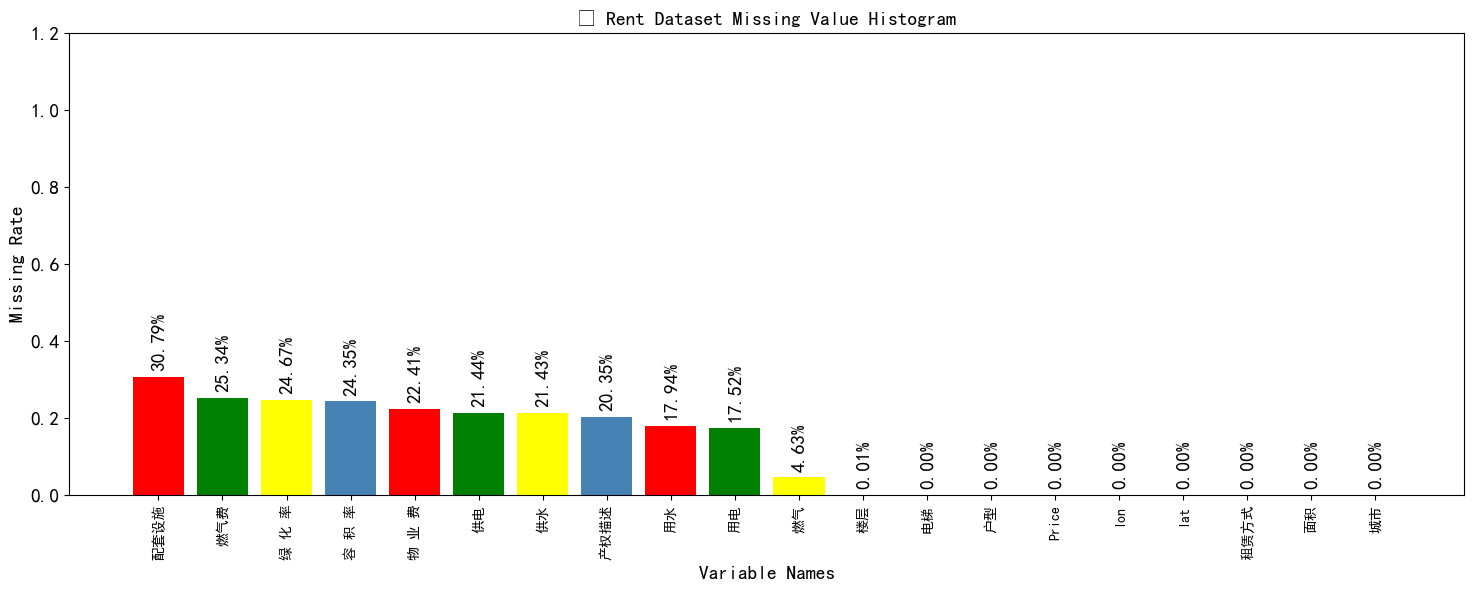

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl

def plot_missing(data, title='Missing Value Histogram'):
    # 统计缺失值数量
    missing = data.isnull().sum().reset_index().rename(columns={0: 'missNum', 'index': 'variable'})
    # 计算缺失比例
    missing['missRate'] = missing['missNum'] / data.shape[0]
    # 按照缺失率排序显示
    miss_analy = missing[missing.missRate >= 0].sort_values(by='missRate', ascending=False)

    # 绘图
    fig = plt.figure(figsize=(18, 6))
    plt.bar(np.arange(miss_analy.shape[0]), miss_analy['missRate'], align='center',
            color=['red', 'green', 'yellow', 'steelblue'])
    plt.title(title)
    plt.xlabel('Variable Names')
    plt.ylabel('Missing Rate')
    plt.xticks(np.arange(miss_analy.shape[0]), miss_analy['variable'])
    pl.xticks(rotation=90)

    # 添加数值显示
    for x, y in enumerate(miss_analy['missRate']):
        plt.text(x, y + 0.02, '{:.2%}'.format(y), ha='center', rotation=90)

    plt.ylim([0, 1.2])
    plt.show()

# 应用到两个数据集
plot_missing(df_price_clean, title='📉 Price Dataset Missing Value Histogram')
plot_missing(df_rent_clean, title='📉 Rent Dataset Missing Value Histogram')


# 接下来对于房价数据进行单独分析

In [264]:
import pandas as pd
import numpy as np
import re

def convert_chinese_num(text):
    """转换中文数字为阿拉伯数字，处理复合数字如"二十五"等情况"""
    if pd.isna(text):
        return text

    # 基础数字映射
    cn_num = {
        '零': 0, '一': 1, '二': 2, '两': 2, '三': 3, '四': 4,
        '五': 5, '六': 6, '七': 7, '八': 8, '九': 9
       
    }
    
    # 单位映射
    cn_unit = {
        '十': 10, '百': 100, '千': 1000, '万': 10000,
        '拾': 10, '佰': 100, '仟': 1000
    }
    
    def process_chinese_number(cn_str):
        if not cn_str:
            return 0
            
        # 特殊处理"十"开头的数字，如"十五"表示15
        if cn_str.startswith('十') or cn_str.startswith('拾'):
            cn_str = '一' + cn_str
            
        result = 0
        unit = 1
        num = 0
        
        for char in reversed(cn_str):
            if char in cn_num:
                num = cn_num[char]
                result += num * unit
            elif char in cn_unit:
                if num == 0:
                    num = 1
                unit = cn_unit[char]
                result = 0
            
        return result
    
    if isinstance(text, str):
        # 查找文本中的中文数字片段
        pattern = r'[零一二两三四五六七八九十百千万壹贰叁肆伍陆柒捌玖拾佰仟]+'
        matches = re.finditer(pattern, text)
        
        # 替换所有找到的中文数字
        result = text
        for match in matches:
            cn_num_str = match.group()
            arab_num = str(process_chinese_number(cn_num_str))
            result = result.replace(cn_num_str, arab_num)
            
        return result
    
    return text

def extract_numeric_features(df):
    """提取数值特征的增强版函数，改进了中文数字处理"""
    df_processed = df.copy()
    
    # 1. 处理建筑面积
    if '建筑面积' in df.columns:
        df_processed['建筑面积_数值'] = df['建筑面积'].apply(convert_chinese_num)\
            .str.extract(r'([\d.]+)').astype(float)
            
    # 2. 处理梯户比例
    if '梯户比例' in df.columns:
        def extract_elevator_household(text):
            if pd.isna(text):
                return np.nan, np.nan
            
            text = convert_chinese_num(str(text))
            elevator = re.search(r'(\d+)梯', text)
            household = re.search(r'(\d+)户', text)
            
            return (float(elevator.group(1)) if elevator else np.nan,
                   float(household.group(1)) if household else np.nan)
        
        # 提取电梯数和户数
        ratios = df['梯户比例'].apply(extract_elevator_household)
        df_processed['电梯数'] = ratios.apply(lambda x: x[0])
        df_processed['户数'] = ratios.apply(lambda x: x[1])
        
        # 计算比例
        mask = (df_processed['电梯数'].notna()) & (df_processed['户数'].notna())
        df_processed['梯户比'] = np.where(mask, 
                                      df_processed['电梯数'] / df_processed['户数'],
                                      np.nan)
    
    # 3. 处理绿化率
    if '绿 化 率' in df.columns:
        df_processed['绿化率_数值'] = df['绿 化 率'].apply(convert_chinese_num)\
            .str.replace('%', '').pipe(pd.to_numeric, errors='coerce') / 100.0
    
    # 4. 处理容积率
    if '容 积 率' in df.columns:
        df_processed['容积率_数值'] = df['容 积 率'].apply(convert_chinese_num)\
            .pipe(pd.to_numeric, errors='coerce')
    
    # 5. 处理物业费
    if '物 业 费' in df.columns:
        def extract_fee(x):
            if pd.isna(x):
                return np.nan
            x = convert_chinese_num(str(x))
            numbers = re.findall(r'[\d.]+', x)
            if not numbers:
                return np.nan
            return np.mean([float(n) for n in numbers[:2]])
            
        df_processed['物业费_数值'] = df['物 业 费'].apply(extract_fee)
    
    # 6. 处理燃气费
    if '燃气费' in df.columns:
        def extract_gas_fee(x):
            if pd.isna(x):
                return np.nan
            x = convert_chinese_num(str(x))
            numbers = re.findall(r'[\d.]+', x)
            if not numbers:
                return np.nan
            return np.mean([float(n) for n in numbers[:2]])
            
        df_processed['燃气费_数值'] = df['燃气费'].apply(extract_gas_fee)
    
    # 7. 处理房屋优势（地铁标记）
    if '房屋优势' in df.columns:
        df_processed['临近地铁'] = df['房屋优势'].str.contains('地铁', na=False).astype(int)
    
    # 显示处理结果统计
    new_features = [col for col in df_processed.columns if col not in df.columns]
    
    print("\n=== 新增特征统计 ===")
    for feature in new_features:
        stats = df_processed[feature]
        print(f"\n特征名：{feature}")
        print(f"数据类型：{stats.dtype}")
        print(f"非空值数量：{stats.count()}")
        print(f"非空值比例：{(stats.count() / len(stats) * 100):.2f}%")
        
        if pd.api.types.is_numeric_dtype(stats):
            print(f"最小值：{stats.min():.4f}")
            print(f"最大值：{stats.max():.4f}")
            print(f"平均值：{stats.mean():.4f}")
            print(f"中位数：{stats.median():.4f}")
            print(f"标准差：{stats.std():.4f}")
            
            # 显示一些样例转换结果
            print("\n样例值转换：")
            original_col = feature.replace('_数值', '')
            if original_col in df.columns:
                sample = df[original_col].dropna().head()
                converted = df_processed[feature].head()
                for orig, conv in zip(sample, converted):
                    print(f"{orig} -> {conv}")
        
        print("-" * 40)
    
    return df_processed

# 应用新函数处理数据
print("开始处理数据...")
df_price_clean= extract_numeric_features(df_price_clean)
df_price_test= extract_numeric_features(df_price_test)



开始处理数据...

=== 新增特征统计 ===

特征名：建筑面积_数值
数据类型：float64
非空值数量：103871
非空值比例：100.00%
最小值：11.7000
最大值：508.1100
平均值：99.2361
中位数：91.1100
标准差：46.7936

样例值转换：
52.3㎡ -> 52.3
127.44㎡ -> 127.44
118.02㎡ -> 118.02
293.23㎡ -> 293.23
39.85㎡ -> 39.85
----------------------------------------

特征名：电梯数
数据类型：float64
非空值数量：101252
非空值比例：97.48%
最小值：1.0000
最大值：20.0000
平均值：1.9396
中位数：2.0000
标准差：1.2253

样例值转换：
----------------------------------------

特征名：户数
数据类型：float64
非空值数量：100879
非空值比例：97.12%
最小值：1.0000
最大值：100.0000
平均值：5.6216
中位数：4.0000
标准差：5.9260

样例值转换：
----------------------------------------

特征名：梯户比
数据类型：float64
非空值数量：100879
非空值比例：97.12%
最小值：0.0200
最大值：20.0000
平均值：0.4493
中位数：0.4444
标准差：0.3245

样例值转换：
----------------------------------------

特征名：绿化率_数值
数据类型：float64
非空值数量：70988
非空值比例：68.34%
最小值：0.0001
最大值：105.0000
平均值：0.4026
中位数：0.3400
标准差：2.7225

样例值转换：
----------------------------------------

特征名：容积率_数值
数据类型：float64
非空值数量：70717
非空值比例：68.08%
最小值：0.0200
最大值：30.0000
平均值：2.7801
中位数：2.5000
标准差：1.6076

样例值转换

In [265]:
import pandas as pd
import numpy as np
import re

# 定义转换中文数字的函数（如果需要）
def convert_chinese_num(text):
    """将中文数字转换为阿拉伯数字"""
    chinese_numerals = {'一': 1, '二': 2, '三': 3, '四': 4, '五': 5, '六': 6, '七': 7, '八': 8, '九': 9, '零': 0}
    for chinese, arabic in chinese_numerals.items():
        text = text.replace(chinese, str(arabic))
    return text

# 提取房屋户型中的房间数量
def extract_room_numbers(text):
    """提取房屋户型中的各类房间数量"""
    if pd.isna(text):
        return 0, 0, 0, 0

    # 转换中文数字
    text = convert_chinese_num(str(text))

    # 提取各类房间数
    bedroom = re.search(r'(\d+)[室房]', text)
    living_room = re.search(r'(\d+)厅', text)
    kitchen = re.search(r'(\d+)厨', text)
    bathroom = re.search(r'(\d+)卫', text)

    # 获取数值，如果没有匹配到则返回0
    bedroom_num = float(bedroom.group(1)) if bedroom else 0
    living_room_num = float(living_room.group(1)) if living_room else 0
    kitchen_num = float(kitchen.group(1)) if kitchen else 0
    bathroom_num = float(bathroom.group(1)) if bathroom else 0

    return bedroom_num, living_room_num, kitchen_num, bathroom_num

# 处理房屋户型数据并返回处理后的 DataFrame
def process_house_layout_data(df, house_layout_column='房屋户型'):
    """处理房屋户型数据并返回处理后的 DataFrame"""
    
    # 确保 DataFrame 中包含'房屋户型'列
    if house_layout_column in df.columns:
        # 提取房间数
        room_info = df[house_layout_column].apply(extract_room_numbers)
        df['卧室数'] = room_info.apply(lambda x: x[0])
        df['客厅数'] = room_info.apply(lambda x: x[1])
        df['厨房数'] = room_info.apply(lambda x: x[2])
        df['卫生间数'] = room_info.apply(lambda x: x[3])

        # 计算总房间数
        df['房间总数'] = (df['卧室数'] + 
                         df['客厅数'] + 
                         df['厨房数'] + 
                         df['卫生间数'])

        # 定义函数检查房间总数为0的行并将相关列置为NaN
        def set_na_if_zero(row):
            if row['房间总数'] == 0:
                row[['卧室数', '客厅数', '厨房数', '卫生间数', '房间总数']] = np.nan
            return row

        # 使用 apply() 函数逐行检查并更新
        df = df.apply(set_na_if_zero, axis=1)

        # 显示统计信息
        print("\n=== 房间数据统计 ===")
        room_columns = ['卧室数', '客厅数', '厨房数', '卫生间数', '房间总数']
        for col in room_columns:
            stats = df[col]
            print(f"\n特征名：{col}")
            print(f"数据类型：{stats.dtype}")
            print(f"非空值数量：{stats.count()}")
            print(f"均值：{stats.mean():.2f}")
            print(f"中位数：{stats.median():.2f}")
            print(f"最小值：{stats.min():.0f}")
            print(f"最大值：{stats.max():.0f}")
            print("-" * 40)

        # 显示转换示例
        print("\n房屋户型转换示例（前5个非空值）：")
        print("-" * 80)
        samples = df[df[house_layout_column].notna()].head()
        print("原始户型 -> [卧室,客厅,厨房,卫生间] = 总房间数")
        for idx, row in samples.iterrows():
            print(f"{row[house_layout_column]} -> [{int(row['卧室数'])},{int(row['客厅数'])},{int(row['厨房数'])},{int(row['卫生间数'])}] = {int(row['房间总数'])}")

        # 返回处理后的数据集
        return df
    else:
        print(f"Error: '{house_layout_column}' column not found in the dataset.")
        return df

# 使用示例：对不同的 DataFrame 进行处理
df_price_clean = process_house_layout_data(df_price_clean)
df_price_test = process_house_layout_data(df_price_test)

# 保存清理后的数据集
df_price_clean.to_csv("cleaned_price_v1（正则化后）.csv", index=False)
df_price_test.to_csv("cleaned_price_test_v1（正则化后）.csv", index=False)



=== 房间数据统计 ===

特征名：卧室数
数据类型：float64
非空值数量：103268
均值：2.61
中位数：3.00
最小值：0
最大值：17
----------------------------------------

特征名：客厅数
数据类型：float64
非空值数量：103268
均值：1.52
中位数：2.00
最小值：0
最大值：9
----------------------------------------

特征名：厨房数
数据类型：float64
非空值数量：103268
均值：0.99
中位数：1.00
最小值：0
最大值：7
----------------------------------------

特征名：卫生间数
数据类型：float64
非空值数量：103268
均值：1.44
中位数：1.00
最小值：0
最大值：12
----------------------------------------

特征名：房间总数
数据类型：float64
非空值数量：103268
均值：6.57
中位数：6.00
最小值：1
最大值：32
----------------------------------------

房屋户型转换示例（前5个非空值）：
--------------------------------------------------------------------------------
原始户型 -> [卧室,客厅,厨房,卫生间] = 总房间数
2室1厅1厨1卫 -> [2,1,1,1] = 5
3室1厅1厨1卫 -> [3,1,1,1] = 6
3室2厅1厨2卫 -> [3,2,1,2] = 8
6室3厅1厨3卫 -> [6,3,1,3] = 13
1房间1卫 -> [1,0,0,1] = 2

=== 房间数据统计 ===

特征名：卧室数
数据类型：float64
非空值数量：33998
均值：2.54
中位数：3.00
最小值：0
最大值：8
----------------------------------------

特征名：客厅数
数据类型：float64
非空值数量：33998
均值：1.48
中位数：2.00
最小值：0
最大值：5
-------------

In [266]:
# 删除df_price_clean中无关列
price_columns_to_drop = ['房屋优势', '梯户比例', '容 积 率', '绿 化 率', '物 业 费', '燃气费',
'建筑面积','房屋户型','交易时间','上次交易','交易权属','房屋用途','所在楼层','房屋朝向','建筑结构',
'物业类别','建筑年代','建筑结构_comm','供水','供电','年份','产权描述','房屋年限','区域', '板块','卧室数','客厅数',
'厨房数','卫生间数']
print("准备从房价数据集中删除以下列：", price_columns_to_drop)

# 检查这些列是否存在于数据集中
existing_columns = [col for col in price_columns_to_drop if col in df_price_clean.columns]
if len(existing_columns) > 0:
    print(f"\n找到 {len(existing_columns)} 个要删除的列：")
    print(existing_columns)
    # 删除这些列
    df_price_clean = df_price_clean.drop(columns=existing_columns)
    print(f"\n删除完成。当前数据集维度：{df_price_clean.shape}")
else:
    print("未找到需要删除的列")

# 显示当前所有列名
print("\n当前租金数据集中的所有列名：")
print("=" * 50)
for col in df_price_clean.columns:
    print(f"- {col}")

# 保存更新后的数据集
df_price_clean.to_csv("cleaned_price_v2(删除无关列后).csv", index=False)
print("\n更新后的数据已保存到 cleaned_price_v2删除无关列后).csv")

#对测试数据集执行相同的列删除操作
df_price_test = df_price_test.drop(columns=price_columns_to_drop)
df_price_test.to_csv("cleaned_price_test_v2(删除无关列后).csv", index=False)



准备从房价数据集中删除以下列： ['房屋优势', '梯户比例', '容 积 率', '绿 化 率', '物 业 费', '燃气费', '建筑面积', '房屋户型', '交易时间', '上次交易', '交易权属', '房屋用途', '所在楼层', '房屋朝向', '建筑结构', '物业类别', '建筑年代', '建筑结构_comm', '供水', '供电', '年份', '产权描述', '房屋年限', '区域', '板块', '卧室数', '客厅数', '厨房数', '卫生间数']

找到 29 个要删除的列：
['房屋优势', '梯户比例', '容 积 率', '绿 化 率', '物 业 费', '燃气费', '建筑面积', '房屋户型', '交易时间', '上次交易', '交易权属', '房屋用途', '所在楼层', '房屋朝向', '建筑结构', '物业类别', '建筑年代', '建筑结构_comm', '供水', '供电', '年份', '产权描述', '房屋年限', '区域', '板块', '卧室数', '客厅数', '厨房数', '卫生间数']

删除完成。当前数据集维度：(103871, 17)

当前租金数据集中的所有列名：
- 城市
- Price
- 装修情况
- 配备电梯
- 产权所属
- lon
- lat
- 建筑面积_数值
- 电梯数
- 户数
- 梯户比
- 绿化率_数值
- 容积率_数值
- 物业费_数值
- 燃气费_数值
- 临近地铁
- 房间总数

更新后的数据已保存到 cleaned_price_v2删除无关列后).csv


In [267]:
#数据填充
import pandas as pd

# 定义需要填充的列
features_to_fill = [
    '电梯数', '户数', '梯户比',
    '绿化率_数值', '容积率_数值',
    '物业费_数值', '燃气费_数值'
]

# 确保所有填充列是数值类型
for col in features_to_fill:
    # 将列转换为数值类型，无法转换的值填充为 NaN
    df_price_clean[col] = pd.to_numeric(df_price_clean[col], errors='coerce')
    df_price_test[col] = pd.to_numeric(df_price_test[col], errors='coerce')

# 定义填充函数
def fill_with_median(data, feature_columns):
    """
    使用整个数据集的中位数填充缺失值。

    :param data: DataFrame
    :param feature_columns: 需要填充的列名列表
    :return: 填充后的 DataFrame
    """
    # 复制数据以避免修改原始数据
    filled_data = data.copy()
    
    # 计算整个数据集的中位数
    median_values = filled_data[feature_columns].median()
    
    # 使用中位数填充缺失值
    filled_data[feature_columns] = filled_data[feature_columns].fillna(median_values)
    
    return filled_data

# 对 df_price_clean 进行填充
df_price_clean = fill_with_median(
    df_price_clean,
    feature_columns=features_to_fill
)

# 对 df_price_test 进行填充
df_price_test = fill_with_median(
    df_price_test,
    feature_columns=features_to_fill
)

# 检查填充前后的缺失值情况（df_price_clean）
print("df_price_clean 填充前的缺失值情况：")
print(df_price_clean[features_to_fill].isnull().sum())

print("\ndf_price_clean 填充后的缺失值情况：")
print(df_price_clean[features_to_fill].isnull().sum())

# 检查填充前后的缺失值情况（df_price_test）
print("\ndf_price_test 填充前的缺失值情况：")
print(df_price_test[features_to_fill].isnull().sum())

print("\ndf_price_test 填充后的缺失值情况：")
print(df_price_test[features_to_fill].isnull().sum())

# 保存结果
df_price_clean.to_csv('cleaned_price_v3(数据填充后).csv', index=False)
df_price_test.to_csv('cleaned_price_test_v3(数据填充后).csv', index=False)

print("数据已成功保存为 cleaned_price_v3(数据填充后).csv 和 cleaned_price_test_v3(数据填充后).csv")


df_price_clean 填充前的缺失值情况：
电梯数       0
户数        0
梯户比       0
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_price_clean 填充后的缺失值情况：
电梯数       0
户数        0
梯户比       0
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_price_test 填充前的缺失值情况：
电梯数       0
户数        0
梯户比       0
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_price_test 填充后的缺失值情况：
电梯数       0
户数        0
梯户比       0
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64
数据已成功保存为 cleaned_price_v3(数据填充后).csv 和 cleaned_price_test_v3(数据填充后).csv


In [268]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 用 df_price_clean 训练 OLS 模型
train_df = df_price_clean.dropna(subset=['房间总数', '建筑面积_数值'])
X_train = train_df[['建筑面积_数值']]
y_train = train_df['房间总数']

# 拟合 OLS 模型
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# 对 df_price_clean 填充缺失值
mask_missing = df_price_clean['房间总数'].isna()

# 预测缺失行的房间总数
X_missing = df_price_clean.loc[mask_missing, ['建筑面积_数值']]
predicted_values = ols_model.predict(X_missing)

# 四舍五入并转为整数
predicted_values = np.round(predicted_values).astype(int)

# 写回原 DataFrame（直接修改）
df_price_clean.loc[mask_missing, '房间总数'] = predicted_values

# 输出结果
print("✅ 房间总数缺失值已用 OLS 模型填补完成！")
print(f"当前剩余空值数量: {df_price_clean['房间总数'].isna().sum()}")

df_price_clean.to_csv('cleaned_price_v4(利用OLS填补房间总数缺失值).csv', index=False)

# 对 df_price_test 填充缺失值
mask_missing_test = df_price_test['房间总数'].isna()

# 预测 df_price_test 中缺失行的房间总数
X_test_missing = df_price_test.loc[mask_missing_test, ['建筑面积_数值']]
predicted_values_test = ols_model.predict(X_test_missing)

# 四舍五入并转为整数
predicted_values_test = np.round(predicted_values_test).astype(int)

# 写回 df_price_test 中
df_price_test.loc[mask_missing_test, '房间总数'] = predicted_values_test

# 输出结果
print("✅ df_price_test 中的房间总数缺失值已用 OLS 模型填补完成！")
print(f"当前剩余空值数量: {df_price_test['房间总数'].isna().sum()}")

df_price_test.to_csv('cleaned_price_test_v4(利用OLS填补房间总数缺失值).csv', index=False)

print("数据已成功保存为 cleaned_price_test_v4(利用OLS填补房间总数缺失值).csv")


✅ 房间总数缺失值已用 OLS 模型填补完成！
当前剩余空值数量: 0
✅ df_price_test 中的房间总数缺失值已用 OLS 模型填补完成！
当前剩余空值数量: 0
数据已成功保存为 cleaned_price_test_v4(利用OLS填补房间总数缺失值).csv


In [269]:
import pandas as pd
import numpy as np

def create_dummies(df):
    """为数据框创建虚拟变量"""
    
    # ===== 城市列虚拟变量 =====
    if '城市' in df.columns:
        city_dummies = pd.get_dummies(df['城市'], prefix='城市', dtype=int)
        df = pd.concat([df, city_dummies], axis=1)
        print("✅ 已为“城市”列创建虚拟变量，共生成以下列：")
        print(list(city_dummies.columns))
    else:
        print("⚠️ 未找到“城市”列，请检查列名。")

    # ===== 产权所属虚拟变量 =====
    if '产权所属' in df.columns:
        df['是否共有产权'] = df['产权所属'].apply(lambda x: 1 if x == '共有' else 0)
        print("✅ 已为“产权所属”列创建虚拟变量：是否共有产权（共有=1，非共有=0）")
    else:
        print("⚠️ 未找到“产权所属”列，请检查列名。")

    # ===== 配备电梯虚拟变量 =====
    if '配备电梯' in df.columns:
        df['是否有电梯'] = df['配备电梯'].apply(lambda x: 0 if x == '无' else 1)
        print("✅ 已为“配备电梯”列创建虚拟变量：是否有电梯（有=1，无=0）")
    else:
        print("⚠️ 未找到“配备电梯”列，请检查列名。")

    # ===== 装修情况列虚拟变量 =====
    if '装修情况' in df.columns:
        # 创建虚拟变量
        df['是否是精装'] = df['装修情况'].apply(lambda x: 1 if x == '精装' else 0)
        df['是否是简装'] = df['装修情况'].apply(lambda x: 1 if x == '简装' else 0)
        df['是否是毛坯'] = df['装修情况'].apply(lambda x: 1 if x == '毛坯' else 0)
        print("✅ 已为“装修情况”列创建虚拟变量：是否是精装（精装=1，否则=0），是否是简装（简装=1，否则=0），是否是毛坯（毛坯=1，否则=0）")
    else:
        print("⚠️ 未找到“装修情况”列，请检查列名。")

    # ===== 删除原始列 =====
    columns_to_drop = ['城市_0', '城市', '产权所属', '配备电梯', '装修情况']
    df = df.drop(columns=columns_to_drop)

    return df

# 对 df_price_clean 和 df_price_test 应用相同处理
df_price_clean = create_dummies(df_price_clean)
df_price_test = create_dummies(df_price_test)

# 保存处理后的数据
df_price_clean.to_csv('cleaned_price_v5（虚拟变量处理后）.csv', index=False)
df_price_test.to_csv('cleaned_price_test_v5（虚拟变量处理后）.csv', index=False)

print("数据已成功保存为 cleaned_price_v5（虚拟变量处理后）.csv 和 cleaned_price_test_v5（虚拟变量处理后）.csv")


✅ 已为“城市”列创建虚拟变量，共生成以下列：
['城市_0', '城市_1', '城市_2', '城市_3', '城市_4', '城市_5', '城市_6', '城市_7', '城市_8', '城市_9', '城市_10', '城市_11']
✅ 已为“产权所属”列创建虚拟变量：是否共有产权（共有=1，非共有=0）
✅ 已为“配备电梯”列创建虚拟变量：是否有电梯（有=1，无=0）
✅ 已为“装修情况”列创建虚拟变量：是否是精装（精装=1，否则=0），是否是简装（简装=1，否则=0），是否是毛坯（毛坯=1，否则=0）
✅ 已为“城市”列创建虚拟变量，共生成以下列：
['城市_0', '城市_1', '城市_2', '城市_3', '城市_4', '城市_5', '城市_6', '城市_7', '城市_8', '城市_9', '城市_10', '城市_11']
✅ 已为“产权所属”列创建虚拟变量：是否共有产权（共有=1，非共有=0）
✅ 已为“配备电梯”列创建虚拟变量：是否有电梯（有=1，无=0）
✅ 已为“装修情况”列创建虚拟变量：是否是精装（精装=1，否则=0），是否是简装（简装=1，否则=0），是否是毛坯（毛坯=1，否则=0）
数据已成功保存为 cleaned_price_v5（虚拟变量处理后）.csv 和 cleaned_price_test_v5（虚拟变量处理后）.csv


d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


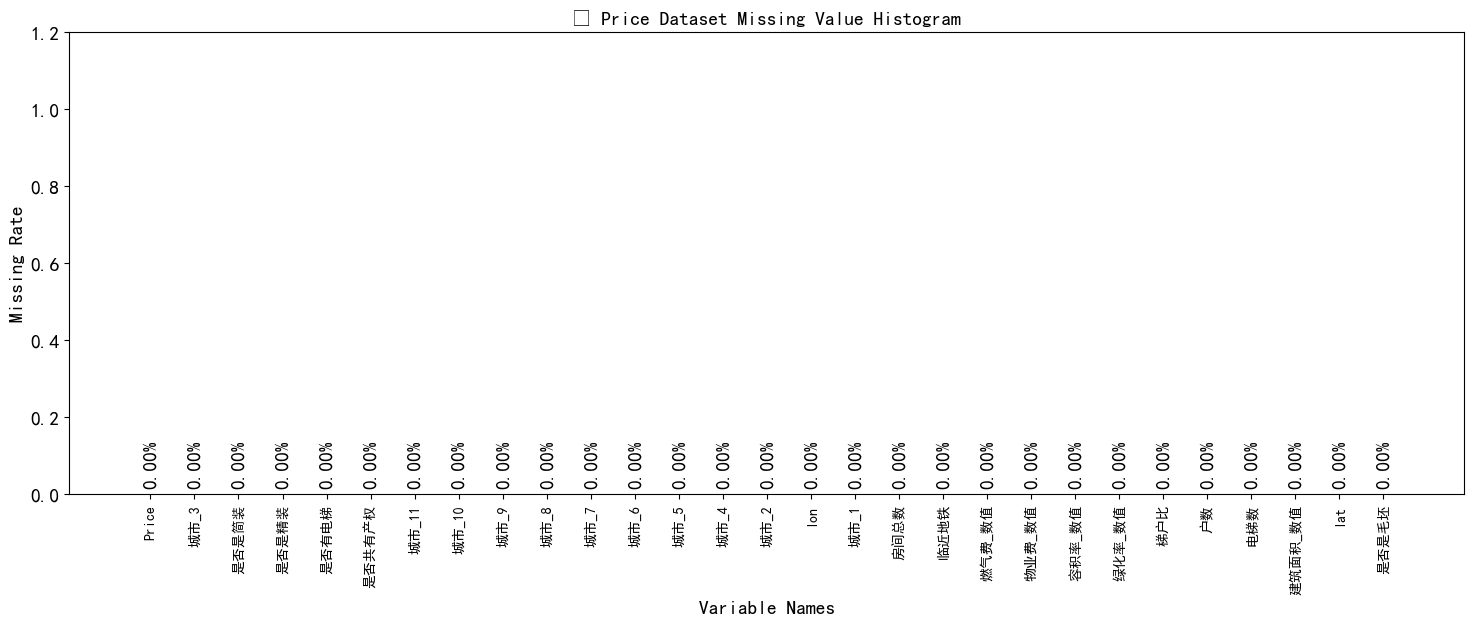

d:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


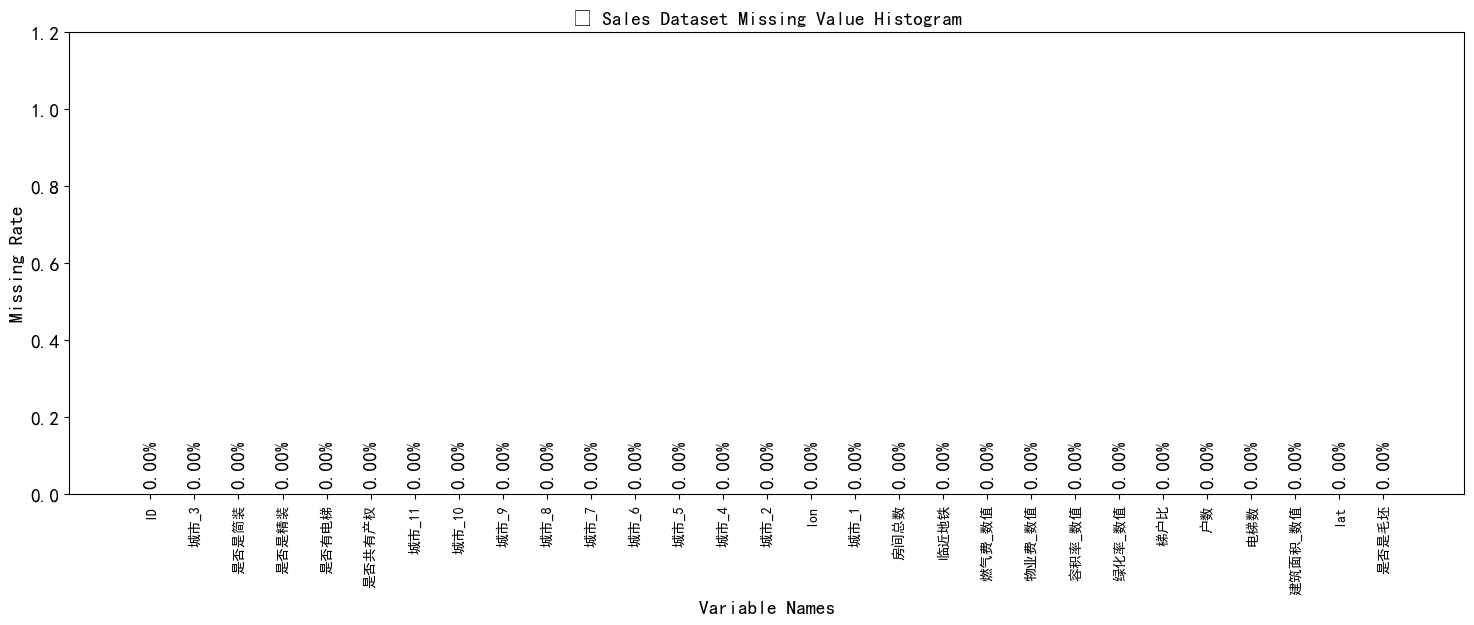

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl

def plot_missing(data, title='Missing Value Histogram'):
    # 统计缺失值数量
    missing = data.isnull().sum().reset_index().rename(columns={0: 'missNum', 'index': 'variable'})
    # 计算缺失比例
    missing['missRate'] = missing['missNum'] / data.shape[0]
    # 按照缺失率排序显示
    miss_analy = missing[missing.missRate >= 0].sort_values(by='missRate', ascending=False)

    # 绘图
    fig = plt.figure(figsize=(18, 6))
    plt.bar(np.arange(miss_analy.shape[0]), miss_analy['missRate'], align='center',
            color=['red', 'green', 'yellow', 'steelblue'])
    plt.title(title)
    plt.xlabel('Variable Names')
    plt.ylabel('Missing Rate')
    plt.xticks(np.arange(miss_analy.shape[0]), miss_analy['variable'])
    pl.xticks(rotation=90)

    # 添加数值显示
    for x, y in enumerate(miss_analy['missRate']):
        plt.text(x, y + 0.02, '{:.2%}'.format(y), ha='center', rotation=90)

    plt.ylim([0, 1.2])
    plt.show()

# 应用到两个数据集
plot_missing(df_price_clean, title='📉 Price Dataset Missing Value Histogram')
plot_missing(df_price_test, title='📈 Sales Dataset Missing Value Histogram')



In [270]:
#删除lat和lon
df_price_clean = df_price_clean.drop(columns=['lat', 'lon'])
df_price_test = df_price_test.drop(columns=['lat', 'lon'])

In [271]:
#划分训练集和测试集
import pandas as pd
from sklearn.model_selection import train_test_split

#目标变量列名为 'Price'
target_column = 'Price'

# 检查目标变量列是否存在
if target_column in df_price_clean.columns:
    # 分离特征和目标变量
    X = df_price_clean.drop(columns=[target_column])
    y = df_price_clean[target_column]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("数据已成功分成80%训练集和20%测试集")
else:
    print(f"⚠️ 未找到目标变量列“{target_column}”，请检查列名。")

#将df_price_test转为预测集
X_predict = df_price_test.drop(columns='ID')

数据已成功分成80%训练集和20%测试集


In [272]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split

def evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict):
    # 删除含有 NaN 的行（按行对齐）
    train_data = pd.concat([X_train, y_train], axis=1).dropna()
    X_train_clean = train_data[X_train.columns]
    y_train_clean = train_data[y_train.name]
    
    test_data = pd.concat([X_test, y_test], axis=1).dropna()
    X_test_clean = test_data[X_test.columns]
    y_test_clean = test_data[y_test.name]
    
    # 建模
    ols_model = LinearRegression()
    ols_model.fit(X_train_clean, y_train_clean)
    
    # In-sample 预测和评估
    y_pred_in_sample = ols_model.predict(X_train_clean)
    mse_in_sample = mean_squared_error(y_train_clean, y_pred_in_sample)
    r2_in_sample = r2_score(y_train_clean, y_pred_in_sample)
    mae_in_sample = mean_absolute_error(y_train_clean, y_pred_in_sample)
    rmae_in_sample = mae_in_sample / np.mean(y_train_clean)
    
    # Out-of-sample 预测和评估
    y_pred_out_of_sample = ols_model.predict(X_test_clean)
    mse_out_of_sample = mean_squared_error(y_test_clean, y_pred_out_of_sample)
    r2_out_of_sample = r2_score(y_test_clean, y_pred_out_of_sample)
    mae_out_of_sample = mean_absolute_error(y_test_clean, y_pred_out_of_sample)
    rmae_out_of_sample = mae_out_of_sample / np.mean(y_test_clean)
    
    # Cross-validation 评估
    # 使用交叉验证来评估模型的性能
    cv_scores_mse = -cross_val_score(ols_model, X_train_clean, y_train_clean, cv=5, scoring='neg_mean_squared_error')
    cv_scores_r2 = cross_val_score(ols_model, X_train_clean, y_train_clean, cv=5, scoring='r2')
    cv_scores_mae = -cross_val_score(ols_model, X_train_clean, y_train_clean, cv=5, scoring='neg_mean_absolute_error')
    
    mse_cv = np.mean(cv_scores_mse)
    r2_cv = np.mean(cv_scores_r2)
    mae_cv = np.mean(cv_scores_mae)
    rmae_cv = mae_cv / np.mean(y_train_clean)
    
    # 对 X_predict 进行预测
    y_predict = ols_model.predict(X_predict)
    
    # 打印结果
    print("In-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_in_sample}")
    print(f"R² (R-squared): {r2_in_sample}")
    print(f"Mean Absolute Error (MAE): {mae_in_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_in_sample}\n")
    
    print("Out-of-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_out_of_sample}")
    print(f"R² (R-squared): {r2_out_of_sample}")
    print(f"Mean Absolute Error (MAE): {mae_out_of_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_out_of_sample}\n")
    
    print("Cross-validation Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_cv}")
    print(f"R² (R-squared): {r2_cv}")
    print(f"Mean Absolute Error (MAE): {mae_cv}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_cv}\n")
    
    # 返回模型评估结果和预测结果
    return mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
           mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
           mse_cv, r2_cv, mae_cv, rmae_cv, y_predict

# 调用函数并输出结果
mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
mse_cv, r2_cv, mae_cv, rmae_cv, y_predict = evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict)

# 查看预测结果
print(f"预测结果：{y_predict[:10]}")  # 打印前10个预测值


In-sample Evaluation:
Mean Squared Error (MSE): 2692284296792.9565
R² (R-squared): 0.5787753137131791
Mean Absolute Error (MAE): 963608.7721778344
Relative Mean Absolute Error (RMAE): 0.4263098997947506

Out-of-sample Evaluation:
Mean Squared Error (MSE): 2675235336357.1187
R² (R-squared): 0.5891778769418636
Mean Absolute Error (MAE): 973237.5196302938
Relative Mean Absolute Error (RMAE): 0.4286563644337208

Cross-validation Evaluation:
Mean Squared Error (MSE): 2696117147270.368
R² (R-squared): 0.5780118221510042
Mean Absolute Error (MAE): 964174.1126193341
Relative Mean Absolute Error (RMAE): 0.4265600119086337

预测结果：[10255618.65899687  4732248.92203829  6593286.96208469  4164463.24138889
  5209105.40944836  4729254.8747816   8155515.88290593  3637192.85305934
  5168339.58374871  5444866.76766994]


In [273]:
import pandas as pd
import numpy as np

def save_predictions_with_ids(df_price_test, y_predict, methodname):
    """
    将预测结果与 df_price_test 的第一列（如 ID）合并，并保存为新的 CSV 文件
    """
    # 假设 df_price_test 中第一列是 ID 或其他标识符列
    # 获取 df_price_test 的第一列（假设是 'ID' 或其他列）
    id_column = df_price_test.iloc[:, 0]
    
    # 创建一个 DataFrame 来保存 ID 和预测结果
    predictions_df = pd.DataFrame({
        'ID': id_column,
        'Price': y_predict  # 将预测结果存入 'Predicted_Price' 列
    })
    
    # 修改文件名拼接部分，确保文件名正确
    file_name = f'predictions_of_Price_{methodname}.csv'  # 使用字符串格式化来拼接文件名
    predictions_df.to_csv(file_name, index=False)
    print(f"预测结果已成功保存为 {file_name} 文件！")

# 调用预测函数并获取预测结果
mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
mse_cv, r2_cv, mae_cv, rmae_cv, y_predict = evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict)

# 查看预测结果并保存与 df_price_test 的 ID 合并
save_predictions_with_ids(df_price_test, y_predict, 'ols')  # 注意这里传递的 'ols' 是字符串


In-sample Evaluation:
Mean Squared Error (MSE): 2692284296792.9565
R² (R-squared): 0.5787753137131791
Mean Absolute Error (MAE): 963608.7721778344
Relative Mean Absolute Error (RMAE): 0.4263098997947506

Out-of-sample Evaluation:
Mean Squared Error (MSE): 2675235336357.1187
R² (R-squared): 0.5891778769418636
Mean Absolute Error (MAE): 973237.5196302938
Relative Mean Absolute Error (RMAE): 0.4286563644337208

Cross-validation Evaluation:
Mean Squared Error (MSE): 2696117147270.368
R² (R-squared): 0.5780118221510042
Mean Absolute Error (MAE): 964174.1126193341
Relative Mean Absolute Error (RMAE): 0.4265600119086337

预测结果已成功保存为 predictions_of_Price_ols.csv 文件！


In [274]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

def evaluate_ridge_lasso(X_train, y_train, X_test, y_test, X_predict, alpha_ridge, alpha_lasso):
    """
    评估优化后的 Ridge 和 Lasso 模型性能

    :param X_train: 训练集特征
    :param y_train: 训练集目标变量
    :param X_test: 测试集特征
    :param y_test: 测试集目标变量
    :param X_predict: 预测集特征
    :param alpha_ridge: Ridge回归的最优alpha值
    :param alpha_lasso: Lasso回归的最优alpha值
    :return: 模型评估指标
    """
    
    # 创建标准化器
    scaler = StandardScaler()
    
    # 对训练集进行标准化
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)  # 测试集使用训练集的均值和标准差
    X_predict_scaled = scaler.transform(X_predict)  # 预测集使用训练集的均值和标准差
    
    # ========== Ridge Regression ==========

    # Ridge模型训练
    ridge_model = Ridge(alpha=alpha_ridge)
    ridge_model.fit(X_train_scaled, y_train)
    
    # In-sample 预测和评估
    y_pred_ridge_in_sample = ridge_model.predict(X_train_scaled)
    mse_ridge_in_sample = mean_squared_error(y_train, y_pred_ridge_in_sample)
    r2_ridge_in_sample = r2_score(y_train, y_pred_ridge_in_sample)
    mae_ridge_in_sample = mean_absolute_error(y_train, y_pred_ridge_in_sample)
    rmae_ridge_in_sample = mae_ridge_in_sample / np.mean(y_train)
    
    # Out-of-sample 预测和评估
    y_pred_ridge_out_of_sample = ridge_model.predict(X_test_scaled)
    mse_ridge_out_of_sample = mean_squared_error(y_test, y_pred_ridge_out_of_sample)
    r2_ridge_out_of_sample = r2_score(y_test, y_pred_ridge_out_of_sample)
    mae_ridge_out_of_sample = mean_absolute_error(y_test, y_pred_ridge_out_of_sample)
    rmae_ridge_out_of_sample = mae_ridge_out_of_sample / np.mean(y_test)
    
    # Cross-validation 评估
    cv_scores_mse_ridge = -cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_scores_r2_ridge = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mae_ridge = -cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
    
    mse_cv_ridge = np.mean(cv_scores_mse_ridge)
    r2_cv_ridge = np.mean(cv_scores_r2_ridge)
    mae_cv_ridge = np.mean(cv_scores_mae_ridge)
    rmae_cv_ridge = mae_cv_ridge / np.mean(y_train)

    # ========== Lasso Regression ==========

    # Lasso模型训练
    lasso_model = Lasso(alpha=alpha_lasso)
    lasso_model.fit(X_train_scaled, y_train)
    
    # In-sample 预测和评估
    y_pred_lasso_in_sample = lasso_model.predict(X_train_scaled)
    mse_lasso_in_sample = mean_squared_error(y_train, y_pred_lasso_in_sample)
    r2_lasso_in_sample = r2_score(y_train, y_pred_lasso_in_sample)
    mae_lasso_in_sample = mean_absolute_error(y_train, y_pred_lasso_in_sample)
    rmae_lasso_in_sample = mae_lasso_in_sample / np.mean(y_train)
    
    # Out-of-sample 预测和评估
    y_pred_lasso_out_of_sample = lasso_model.predict(X_test_scaled)
    mse_lasso_out_of_sample = mean_squared_error(y_test, y_pred_lasso_out_of_sample)
    r2_lasso_out_of_sample = r2_score(y_test, y_pred_lasso_out_of_sample)
    mae_lasso_out_of_sample = mean_absolute_error(y_test, y_pred_lasso_out_of_sample)
    rmae_lasso_out_of_sample = mae_lasso_out_of_sample / np.mean(y_test)
    
    # Cross-validation 评估
    cv_scores_mse_lasso = -cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_scores_r2_lasso = cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mae_lasso = -cross_val_score(lasso_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error')
    
    mse_cv_lasso = np.mean(cv_scores_mse_lasso)
    r2_cv_lasso = np.mean(cv_scores_r2_lasso)
    mae_cv_lasso = np.mean(cv_scores_mae_lasso)
    rmae_cv_lasso = mae_cv_lasso / np.mean(y_train)

    # 对预测集进行预测
    y_pred_ridge_predict = ridge_model.predict(X_predict_scaled)
    y_pred_lasso_predict = lasso_model.predict(X_predict_scaled)


    # 打印结果
    print("Ridge Regression In-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_ridge_in_sample}")
    print(f"R² (R-squared): {r2_ridge_in_sample}")
    print(f"Mean Absolute Error (MAE): {mae_ridge_in_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_ridge_in_sample}\n")
    
    print("Ridge Regression Out-of-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_ridge_out_of_sample}")
    print(f"R² (R-squared): {r2_ridge_out_of_sample}")
    print(f"Mean Absolute Error (MAE): {mae_ridge_out_of_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_ridge_out_of_sample}\n")
    
    print("Ridge Regression Cross-validation Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_cv_ridge}")
    print(f"R² (R-squared): {r2_cv_ridge}")
    print(f"Mean Absolute Error (MAE): {mae_cv_ridge}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_cv_ridge}\n")

    print("Lasso Regression In-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_lasso_in_sample}")
    print(f"R² (R-squared): {r2_lasso_in_sample}")
    print(f"Mean Absolute Error (MAE): {mae_lasso_in_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_lasso_in_sample}\n")
    
    print("Lasso Regression Out-of-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_lasso_out_of_sample}")
    print(f"R² (R-squared): {r2_lasso_out_of_sample}")
    print(f"Mean Absolute Error (MAE): {mae_lasso_out_of_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_lasso_out_of_sample}\n")
    
    print("Lasso Regression Cross-validation Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_cv_lasso}")
    print(f"R² (R-squared): {r2_cv_lasso}")
    print(f"Mean Absolute Error (MAE): {mae_cv_lasso}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_cv_lasso}\n")
    
    # 返回评估结果和预测结果
    return mse_ridge_in_sample, r2_ridge_in_sample, mae_ridge_in_sample, rmae_ridge_in_sample, \
           mse_ridge_out_of_sample, r2_ridge_out_of_sample, mae_ridge_out_of_sample, rmae_ridge_out_of_sample, \
           mse_cv_ridge, r2_cv_ridge, mae_cv_ridge, rmae_cv_ridge, \
           mse_lasso_in_sample, r2_lasso_in_sample, mae_lasso_in_sample, rmae_lasso_in_sample, \
           mse_lasso_out_of_sample, r2_lasso_out_of_sample, mae_lasso_out_of_sample, rmae_lasso_out_of_sample, \
           mse_cv_lasso, r2_cv_lasso, mae_cv_lasso, rmae_cv_lasso,y_pred_ridge_predict,y_pred_lasso_predict 




Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

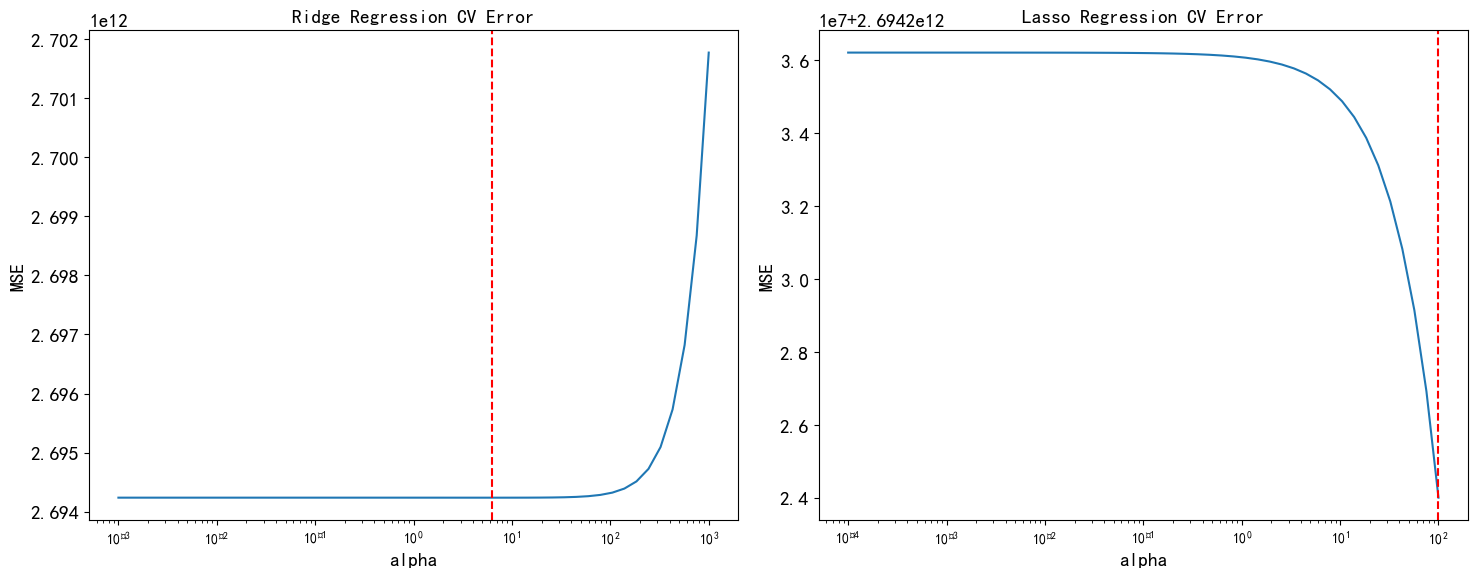

Optimized Ridge alpha: 6.25055192527397
Optimized Lasso alpha: 100.0


In [275]:
# 参数调优及可视化模块
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

def tune_hyperparameters(X_train, y_train):
    """ 参数调优与可视化分析 """
    # 创建标准化器
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # 设置参数搜索空间（对数尺度）
    alphas_ridge = np.logspace(-3, 3, 50)  # 10^-3 到 10^3
    alphas_lasso = np.logspace(-4, 2, 50)  # Lasso通常需要更小的alpha范围

    # 使用交叉验证网格搜索寻找最优参数
    # Ridge参数优化
    ridge_cv = GridSearchCV(Ridge(), 
                          param_grid={'alpha': alphas_ridge},
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='neg_mean_squared_error')
    ridge_cv.fit(X_train_scaled, y_train)
    best_alpha_ridge = ridge_cv.best_params_['alpha']

    # Lasso参数优化
    lasso_cv = GridSearchCV(Lasso(max_iter=10000),  # 增加迭代次数确保收敛
                          param_grid={'alpha': alphas_lasso},
                          cv=KFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='neg_mean_squared_error')
    lasso_cv.fit(X_train_scaled, y_train)
    best_alpha_lasso = lasso_cv.best_params_['alpha']

    # 可视化参数选择过程
    plt.figure(figsize=(15, 6))
    
    # Ridge参数可视化
    plt.subplot(1, 2, 1)
    plt.semilogx(alphas_ridge, -ridge_cv.cv_results_['mean_test_score'])
    plt.axvline(best_alpha_ridge, color='r', linestyle='--')
    plt.title('Ridge Regression CV Error')
    plt.xlabel('alpha')
    plt.ylabel('MSE')
    plt.annotate(f'Optimal alpha: {best_alpha_ridge:.4f}', 
                 xy=(best_alpha_ridge, 0), 
                 xytext=(0.1, 0.2), 
                 textcoords='axes fraction',
                 arrowprops=dict(facecolor='red', shrink=0.05))

    # Lasso参数可视化
    plt.subplot(1, 2, 2)
    plt.semilogx(alphas_lasso, -lasso_cv.cv_results_['mean_test_score'])
    plt.axvline(best_alpha_lasso, color='r', linestyle='--')
    plt.title('Lasso Regression CV Error')
    plt.xlabel('alpha')
    plt.ylabel('MSE')
    plt.annotate(f'Optimal alpha: {best_alpha_lasso:.4f}', 
                 xy=(best_alpha_lasso, 0), 
                 xytext=(0.1, 0.2), 
                 textcoords='axes fraction',
                 arrowprops=dict(facecolor='red', shrink=0.05))

    plt.tight_layout()
    plt.show()

    return best_alpha_ridge, best_alpha_lasso

# 执行参数调优
optimal_ridge_alpha, optimal_lasso_alpha = tune_hyperparameters(X_train_selected, y_train)

print(f"Optimized Ridge alpha: {optimal_ridge_alpha}")
print(f"Optimized Lasso alpha: {optimal_lasso_alpha}")



In [276]:
# 使用优化后的参数运行评估
mse_ridge_in_sample, r2_ridge_in_sample, mae_ridge_in_sample, rmae_ridge_in_sample, \
mse_ridge_out_of_sample, r2_ridge_out_of_sample, mae_ridge_out_of_sample, rmae_ridge_out_of_sample, \
mse_cv_ridge, r2_cv_ridge, mae_cv_ridge, rmae_cv_ridge, \
mse_lasso_in_sample, r2_lasso_in_sample, mae_lasso_in_sample, rmae_lasso_in_sample, \
mse_lasso_out_of_sample, r2_lasso_out_of_sample, mae_lasso_out_of_sample, rmae_lasso_out_of_sample, \
mse_cv_lasso, r2_cv_lasso, mae_cv_lasso, rmae_cv_lasso,y_pred_ridge_predict, y_pred_lasso_predict = evaluate_ridge_lasso(
    X_train, y_train, X_test, y_test, X_predict,
    alpha_ridge=optimal_ridge_alpha,  # 应用优化后的参数
    alpha_lasso=optimal_lasso_alpha   # 应用优化后的参数
)

# 保存预测结果
def save_predictions_with_ids(df_price_test, y_predict, methodname):
    """
    将预测结果与 df_price_test 的第一列（如 ID）合并，并保存为新的 CSV 文件
    """
    # 假设 df_price_test 中第一列是 ID 或其他标识符列
    # 获取 df_price_test 的第一列（假设是 'ID' 或其他列）
    id_column = df_price_test.iloc[:, 0]
    
    # 创建一个 DataFrame 来保存 ID 和预测结果
    predictions_df = pd.DataFrame({
        'ID': id_column,
        'Price': y_predict  # 将预测结果存入 'Predicted_Price' 列
    })
    
    # 修改文件名拼接部分，确保文件名正确
    file_name = f'predictions_of_Price_{methodname}.csv'  # 使用字符串格式化来拼接文件名
    predictions_df.to_csv(file_name, index=False)
    print(f"预测结果已成功保存为 {file_name} 文件！")

# 调用预测函数并获取预测结果
mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
mse_cv, r2_cv, mae_cv, rmae_cv, y_predict = evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict)


# 查看预测结果并保存与 df_price_test 的 ID 合并
save_predictions_with_ids(df_price_test, y_pred_ridge_predict, 'ridge')
save_predictions_with_ids(df_price_test, y_pred_lasso_predict, 'lasso')

Ridge Regression In-sample Evaluation:
Mean Squared Error (MSE): 2692284521353.147
R² (R-squared): 0.5787752785793354
Mean Absolute Error (MAE): 963539.9731449742
Relative Mean Absolute Error (RMAE): 0.4262794624329795

Ridge Regression Out-of-sample Evaluation:
Mean Squared Error (MSE): 2675233977304.8784
R² (R-squared): 0.5891780856445221
Mean Absolute Error (MAE): 973173.3507281336
Relative Mean Absolute Error (RMAE): 0.42862810164303

Ridge Regression Cross-validation Evaluation:
Mean Squared Error (MSE): 2696116558731.2354
R² (R-squared): 0.5780121812819026
Mean Absolute Error (MAE): 964088.3221113613
Relative Mean Absolute Error (RMAE): 0.42652205735289156

Lasso Regression In-sample Evaluation:
Mean Squared Error (MSE): 2692284869847.407
R² (R-squared): 0.5787752240552327
Mean Absolute Error (MAE): 963500.1465950666
Relative Mean Absolute Error (RMAE): 0.42626184277966117

Lasso Regression Out-of-sample Evaluation:
Mean Squared Error (MSE): 2675252805592.2905
R² (R-squared): 0.5

# 下面对rent数据进行建模分析

In [382]:
import pandas as pd
import numpy as np
import re

def convert_chinese_num(text):
    """转换中文数字为阿拉伯数字，处理复合数字如"二十五"等情况"""
    if pd.isna(text):
        return text

    # 基础数字映射
    cn_num = {
        '零': 0, '一': 1, '二': 2, '两': 2, '三': 3, '四': 4,
        '五': 5, '六': 6, '七': 7, '八': 8, '九': 9
       
    }
    
    # 单位映射
    cn_unit = {
        '十': 10, '百': 100, '千': 1000, '万': 10000,
        '拾': 10, '佰': 100, '仟': 1000
    }
    
    def process_chinese_number(cn_str):
        if not cn_str:
            return 0
            
        # 特殊处理"十"开头的数字，如"十五"表示15
        if cn_str.startswith('十') or cn_str.startswith('拾'):
            cn_str = '一' + cn_str
            
        result = 0
        unit = 1
        num = 0
        
        for char in reversed(cn_str):
            if char in cn_num:
                num = cn_num[char]
                result += num * unit
            elif char in cn_unit:
                if num == 0:
                    num = 1
                unit = cn_unit[char]
                result = 0
            
        return result
    
    if isinstance(text, str):
        # 查找文本中的中文数字片段
        pattern = r'[零一二两三四五六七八九十百千万壹贰叁肆伍陆柒捌玖拾佰仟]+'
        matches = re.finditer(pattern, text)
        
        # 替换所有找到的中文数字
        result = text
        for match in matches:
            cn_num_str = match.group()
            arab_num = str(process_chinese_number(cn_num_str))
            result = result.replace(cn_num_str, arab_num)
            
        return result
    
    return text

def extract_numeric_features(df):
    """提取数值特征的增强版函数，改进了中文数字处理"""
    df_processed = df.copy()
    
    # 1. 处理建筑面积
    if '面积' in df.columns:
        df_processed['建筑面积_数值'] = df['面积'].apply(convert_chinese_num)\
            .str.extract(r'([\d.]+)').astype(float)
            

    # 2. 处理绿化率
    if '绿 化 率' in df.columns:
        df_processed['绿化率_数值'] = df['绿 化 率'].apply(convert_chinese_num)\
            .str.replace('%', '').pipe(pd.to_numeric, errors='coerce') / 100.0
    
    # 3. 处理容积率
    if '容 积 率' in df.columns:
        df_processed['容积率_数值'] = df['容 积 率'].apply(convert_chinese_num)\
            .pipe(pd.to_numeric, errors='coerce')
    
    # 4. 处理物业费
    if '物 业 费' in df.columns:
        def extract_fee(x):
            if pd.isna(x):
                return np.nan
            x = convert_chinese_num(str(x))
            numbers = re.findall(r'[\d.]+', x)
            if not numbers:
                return np.nan
            return np.mean([float(n) for n in numbers[:2]])
            
        df_processed['物业费_数值'] = df['物 业 费'].apply(extract_fee)
    
    # 5. 处理燃气费
    if '燃气费' in df.columns:
        def extract_gas_fee(x):
            if pd.isna(x):
                return np.nan
            x = convert_chinese_num(str(x))
            numbers = re.findall(r'[\d.]+', x)
            if not numbers:
                return np.nan
            return np.mean([float(n) for n in numbers[:2]])
            
        df_processed['燃气费_数值'] = df['燃气费'].apply(extract_gas_fee)
    

    # 显示处理结果统计
    new_features = [col for col in df_processed.columns if col not in df.columns]
    
    print("\n=== 新增特征统计 ===")
    for feature in new_features:
        stats = df_processed[feature]
        print(f"\n特征名：{feature}")
        print(f"数据类型：{stats.dtype}")
        print(f"非空值数量：{stats.count()}")
        print(f"非空值比例：{(stats.count() / len(stats) * 100):.2f}%")
        
        if pd.api.types.is_numeric_dtype(stats):
            print(f"最小值：{stats.min():.4f}")
            print(f"最大值：{stats.max():.4f}")
            print(f"平均值：{stats.mean():.4f}")
            print(f"中位数：{stats.median():.4f}")
            print(f"标准差：{stats.std():.4f}")
            
            # 显示一些样例转换结果
            print("\n样例值转换：")
            original_col = feature.replace('_数值', '')
            if original_col in df.columns:
                sample = df[original_col].dropna().head()
                converted = df_processed[feature].head()
                for orig, conv in zip(sample, converted):
                    print(f"{orig} -> {conv}")
        
        print("-" * 40)
    
    return df_processed

# 应用新函数处理数据
print("开始处理数据...")
df_rent_clean= extract_numeric_features(df_rent_clean)
df_rent_test= extract_numeric_features(df_rent_test)


# 保存清理后的数据集
df_rent_clean.to_csv("cleaned_rent_v1（正则化后）.csv", index=False)
df_rent_test.to_csv("cleaned_rent_test_v1（正则化后）.csv", index=False)


开始处理数据...

=== 新增特征统计 ===

特征名：建筑面积_数值
数据类型：float64
非空值数量：98899
非空值比例：100.00%
最小值：6.0500
最大值：440.0000
平均值：80.5065
中位数：79.0000
标准差：42.6436

样例值转换：
----------------------------------------

特征名：绿化率_数值
数据类型：float64
非空值数量：74497
非空值比例：75.33%
最小值：0.0001
最大值：105.0000
平均值：0.4617
中位数：0.3500
标准差：3.6972

样例值转换：
----------------------------------------

特征名：容积率_数值
数据类型：float64
非空值数量：74819
非空值比例：75.65%
最小值：0.0200
最大值：30.0000
平均值：3.0609
中位数：2.6700
标准差：1.7513

样例值转换：
----------------------------------------

特征名：物业费_数值
数据类型：float64
非空值数量：76740
非空值比例：77.59%
最小值：0.0200
最大值：76.4500
平均值：2.8377
中位数：2.2000
标准差：3.8878

样例值转换：
----------------------------------------

特征名：燃气费_数值
数据类型：float64
非空值数量：73842
非空值比例：74.66%
最小值：0.4000
最大值：5.0000
平均值：2.8837
中位数：2.9500
标准差：0.5879

样例值转换：
2.61元/m³ -> 2.61
2.61元/m³ -> 2.61
2.61-2.63元/m³ -> 2.62
2.61元/m³ -> 2.61
2.61元/m³ -> 2.61
----------------------------------------

=== 新增特征统计 ===

特征名：建筑面积_数值
数据类型：float64
非空值数量：9773
非空值比例：100.00%
最小值：7.0000
最大值：380.2200
平均值：81.3131


In [383]:
import pandas as pd
import numpy as np
import re

# 定义转换中文数字的函数（如果需要）
def convert_chinese_num(text):
    """将中文数字转换为阿拉伯数字"""
    chinese_numerals = {'一': 1, '二': 2, '三': 3, '四': 4, '五': 5, '六': 6, '七': 7, '八': 8, '九': 9, '零': 0}
    for chinese, arabic in chinese_numerals.items():
        text = text.replace(chinese, str(arabic))
    return text

# 提取房屋户型中的房间数量
def extract_room_numbers(text):
    """提取房屋户型中的各类房间数量"""
    if pd.isna(text):
        return 0, 0, 0, 0

    # 转换中文数字
    text = convert_chinese_num(str(text))

    # 提取各类房间数
    bedroom = re.search(r'(\d+)[室房]', text)
    living_room = re.search(r'(\d+)厅', text)
    kitchen = re.search(r'(\d+)厨', text)
    bathroom = re.search(r'(\d+)卫', text)

    # 获取数值，如果没有匹配到则返回0
    bedroom_num = float(bedroom.group(1)) if bedroom else 0
    living_room_num = float(living_room.group(1)) if living_room else 0
    kitchen_num = float(kitchen.group(1)) if kitchen else 0
    bathroom_num = float(bathroom.group(1)) if bathroom else 0

    return bedroom_num, living_room_num, kitchen_num, bathroom_num

# 处理房屋户型数据并返回处理后的 DataFrame
def process_house_layout_data(df, house_layout_column='户型'):
    """处理房屋户型数据并返回处理后的 DataFrame"""
    
    # 确保 DataFrame 中包含'房屋户型'列
    if house_layout_column in df.columns:
        # 提取房间数
        room_info = df[house_layout_column].apply(extract_room_numbers)
        df['卧室数'] = room_info.apply(lambda x: x[0])
        df['客厅数'] = room_info.apply(lambda x: x[1])
        df['厨房数'] = room_info.apply(lambda x: x[2])
        df['卫生间数'] = room_info.apply(lambda x: x[3])

        # 计算总房间数
        df['房间总数'] = (df['卧室数'] + 
                         df['客厅数'] + 
                         df['厨房数'] + 
                         df['卫生间数'])

        # 定义函数检查房间总数为0的行并将相关列置为NaN
        def set_na_if_zero(row):
            if row['房间总数'] == 0:
                row[['卧室数', '客厅数', '厨房数', '卫生间数', '房间总数']] = np.nan
            return row

        # 使用 apply() 函数逐行检查并更新
        df = df.apply(set_na_if_zero, axis=1)

        # 显示统计信息
        print("\n=== 房间数据统计 ===")
        room_columns = ['卧室数', '客厅数', '厨房数', '卫生间数', '房间总数']
        for col in room_columns:
            stats = df[col]
            print(f"\n特征名：{col}")
            print(f"数据类型：{stats.dtype}")
            print(f"非空值数量：{stats.count()}")
            print(f"均值：{stats.mean():.2f}")
            print(f"中位数：{stats.median():.2f}")
            print(f"最小值：{stats.min():.0f}")
            print(f"最大值：{stats.max():.0f}")
            print("-" * 40)

        # 显示转换示例
        print("\n房屋户型转换示例（前5个非空值）：")
        print("-" * 80)
        samples = df[df[house_layout_column].notna()].head()
        print("原始户型 -> [卧室,客厅,厨房,卫生间] = 总房间数")
        for idx, row in samples.iterrows():
            print(f"{row[house_layout_column]} -> [{int(row['卧室数'])},{int(row['客厅数'])},{int(row['厨房数'])},{int(row['卫生间数'])}] = {int(row['房间总数'])}")

        # 返回处理后的数据集
        return df
    else:
        print(f"Error: '{house_layout_column}' column not found in the dataset.")
        return df

# 使用示例：对不同的 DataFrame 进行处理
df_rent_clean = process_house_layout_data(df_rent_clean)
df_rent_test = process_house_layout_data(df_rent_test)

# 保存清理后的数据集
df_rent_clean.to_csv("cleaned_rent_v1（正则化后）.csv", index=False)
df_rent_test.to_csv("cleaned_rent_test_v1（正则化后）.csv", index=False)



=== 房间数据统计 ===

特征名：卧室数
数据类型：float64
非空值数量：95122
均值：2.26
中位数：2.00
最小值：0
最大值：12
----------------------------------------

特征名：客厅数
数据类型：float64
非空值数量：95122
均值：1.34
中位数：1.00
最小值：0
最大值：7
----------------------------------------

特征名：厨房数
数据类型：float64
非空值数量：95122
均值：0.00
中位数：0.00
最小值：0
最大值：0
----------------------------------------

特征名：卫生间数
数据类型：float64
非空值数量：95122
均值：0.46
中位数：0.00
最小值：0
最大值：9
----------------------------------------

特征名：房间总数
数据类型：float64
非空值数量：95122
均值：4.06
中位数：4.00
最小值：1
最大值：21
----------------------------------------

房屋户型转换示例（前5个非空值）：
--------------------------------------------------------------------------------
原始户型 -> [卧室,客厅,厨房,卫生间] = 总房间数
1室1厅1卫 -> [1,1,0,1] = 3
1室1厅1卫 -> [1,1,0,1] = 3
1室1厅1卫 -> [1,1,0,1] = 3
3室1厅2卫 -> [3,1,0,2] = 6
1室1厅1卫 -> [1,1,0,1] = 3

=== 房间数据统计 ===

特征名：卧室数
数据类型：float64
非空值数量：9768
均值：2.35
中位数：2.00
最小值：0
最大值：10
----------------------------------------

特征名：客厅数
数据类型：float64
非空值数量：9768
均值：1.36
中位数：1.00
最小值：0
最大值：5
----------------------------

In [384]:
# 删除df_rent_clean中无关列
rent_columns_to_drop = ['燃气费','绿 化 率','容 积 率','物 业 费','产权描述','户型']
print("准备从租金数据集中删除以下列：", rent_columns_to_drop)

# 检查这些列是否存在于数据集中
existing_columns = [col for col in rent_columns_to_drop if col in df_rent_clean.columns]
if len(existing_columns) > 0:
    print(f"\n找到 {len(existing_columns)} 个要删除的列：")
    print(existing_columns)
    # 删除这些列
    df_rent_clean = df_rent_clean.drop(columns=existing_columns)
    df_rent_test = df_rent_test.drop(columns=existing_columns)
    print(f"\n删除完成。当前数据集维度：{df_rent_clean.shape}")
    print(f"\n删除完成。当前数据集维度：{df_rent_test.shape}")
else:
    print("未找到需要删除的列")

# 显示当前所有列名
print("\n当前租金数据集中的所有列名：")
print("=" * 50)
for col in df_rent_clean.columns:
    print(col)

# 显示当前所有列名
print("\n当前租金测试数据集中的所有列名：")
print("=" * 50)
for col in df_rent_test.columns:
    print(col) 



df_rent_clean.to_csv("cleaned_rent_v2(删除无关列后).csv", index=False)
print("\n更新后的数据已保存到 cleaned_rent_v2(删除无关列后).csv")

#对测试数据集执行相同的列删除操作

df_rent_test.to_csv("cleaned_rent_test_v2(删除无关列后).csv", index=False)
print("\n更新后的数据已保存到 cleaned_rent_test_v2(删除无关列后).csv")   




准备从租金数据集中删除以下列： ['燃气费', '绿 化 率', '容 积 率', '物 业 费', '产权描述', '户型']

找到 6 个要删除的列：
['燃气费', '绿 化 率', '容 积 率', '物 业 费', '产权描述', '户型']

删除完成。当前数据集维度：(98899, 24)

删除完成。当前数据集维度：(9773, 24)

当前租金数据集中的所有列名：
城市
Price
楼层
面积
租赁方式
电梯
用水
用电
燃气
配套设施
lon
lat
供水
供电
建筑面积_数值
绿化率_数值
容积率_数值
物业费_数值
燃气费_数值
卧室数
客厅数
厨房数
卫生间数
房间总数

当前租金测试数据集中的所有列名：
ID
城市
楼层
面积
租赁方式
电梯
用水
用电
燃气
配套设施
lon
lat
供水
供电
建筑面积_数值
绿化率_数值
容积率_数值
物业费_数值
燃气费_数值
卧室数
客厅数
厨房数
卫生间数
房间总数

更新后的数据已保存到 cleaned_rent_v2(删除无关列后).csv

更新后的数据已保存到 cleaned_rent_test_v2(删除无关列后).csv


In [385]:
import pandas as pd

# 定义需要填充的列
features_to_fill = [
    '绿化率_数值', '容积率_数值',
    '物业费_数值', '燃气费_数值'
]

# 确保所有填充列是数值类型
for col in features_to_fill:
    # 将列转换为数值类型，无法转换的值填充为 NaN
    df_rent_clean[col] = pd.to_numeric(df_rent_clean[col], errors='coerce')
    df_rent_test[col] = pd.to_numeric(df_rent_test[col], errors='coerce')

# 定义填充函数
def fill_with_median(data, feature_columns):
    """
    使用整个数据集的中位数填充缺失值。

    :param data: DataFrame
    :param feature_columns: 需要填充的列名列表
    :return: 填充后的 DataFrame
    """
    # 复制数据以避免修改原始数据
    filled_data = data.copy()
    
    # 计算整个数据集的中位数
    median_values = filled_data[feature_columns].median()
    
    # 使用中位数填充缺失值
    filled_data[feature_columns] = filled_data[feature_columns].fillna(median_values)
    
    return filled_data

# 对 df_rent_clean 进行填充
df_rent_clean = fill_with_median(
    df_rent_clean,
    feature_columns=features_to_fill
)

# 对 df_rent_test 进行填充
df_rent_test = fill_with_median(
    df_rent_test,
    feature_columns=features_to_fill
)

# 检查填充前后的缺失值情况（df_rent_clean）
print("df_rent_clean 填充前的缺失值情况：")
print(df_rent_clean[features_to_fill].isnull().sum())

print("\ndf_rent_clean 填充后的缺失值情况：")
print(df_rent_clean[features_to_fill].isnull().sum())

# 检查填充前后的缺失值情况（df_rent_test）
print("\ndf_rent_test 填充前的缺失值情况：")
print(df_rent_test[features_to_fill].isnull().sum())

print("\ndf_rent_test 填充后的缺失值情况：")
print(df_rent_test[features_to_fill].isnull().sum())

# 保存结果
df_rent_clean.to_csv('cleaned_rent_v3(数据填充后).csv', index=False)
df_rent_test.to_csv('cleaned_rent_test_v3(数据填充后).csv', index=False)

print("数据已成功保存为 cleaned_rent_v3(数据填充后).csv 和 cleaned_rent_test_v3(数据填充后).csv")


df_rent_clean 填充前的缺失值情况：
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_rent_clean 填充后的缺失值情况：
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_rent_test 填充前的缺失值情况：
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64

df_rent_test 填充后的缺失值情况：
绿化率_数值    0
容积率_数值    0
物业费_数值    0
燃气费_数值    0
dtype: int64
数据已成功保存为 cleaned_rent_v3(数据填充后).csv 和 cleaned_rent_test_v3(数据填充后).csv


In [386]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# 用 df_rent_clean 训练 OLS 模型
train_df = df_rent_clean.dropna(subset=['房间总数', '建筑面积_数值'])
X_train = train_df[['建筑面积_数值']]
y_train = train_df['房间总数']

# 拟合 OLS 模型
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# 对 df_rent_clean 填充缺失值
mask_missing = df_rent_clean['房间总数'].isna()

# 预测缺失行的房间总数
X_missing = df_rent_clean.loc[mask_missing, ['建筑面积_数值']]
predicted_values = ols_model.predict(X_missing)

# 四舍五入并转为整数
predicted_values = np.round(predicted_values).astype(int)

# 写回原 DataFrame（直接修改）
df_rent_clean.loc[mask_missing, '房间总数'] = predicted_values

# 输出结果
print("✅ 房间总数缺失值已用 OLS 模型填补完成！")
print(f"当前剩余空值数量: {df_rent_clean['房间总数'].isna().sum()}")

df_rent_clean.to_csv('cleaned_rent_v4(利用OLS填补房间总数缺失值).csv', index=False)

# 对 df_rent_test 填充缺失值
mask_missing_test = df_rent_test['房间总数'].isna()

# 预测 df_rent_test 中缺失行的房间总数
X_test_missing = df_rent_test.loc[mask_missing_test, ['建筑面积_数值']]
predicted_values_test = ols_model.predict(X_test_missing)

# 四舍五入并转为整数
predicted_values_test = np.round(predicted_values_test).astype(int)

# 写回 df_rent_test 中
df_rent_test.loc[mask_missing_test, '房间总数'] = predicted_values_test

# 输出结果
print("✅ df_rent_test 中的房间总数缺失值已用 OLS 模型填补完成！")
print(f"当前剩余空值数量: {df_rent_test['房间总数'].isna().sum()}")

df_rent_test.to_csv('cleaned_rent_test_v4(利用OLS填补房间总数缺失值).csv', index=False)

print("数据已成功保存为 cleaned_rent_test_v4(利用OLS填补房间总数缺失值).csv")


✅ 房间总数缺失值已用 OLS 模型填补完成！
当前剩余空值数量: 0
✅ df_rent_test 中的房间总数缺失值已用 OLS 模型填补完成！
当前剩余空值数量: 0
数据已成功保存为 cleaned_rent_test_v4(利用OLS填补房间总数缺失值).csv


In [387]:
import pandas as pd
import numpy as np

def create_dummies(df):
    """为数据框创建虚拟变量"""
    
    # ===== 城市列虚拟变量 =====
    if '城市' in df.columns:
        city_dummies = pd.get_dummies(df['城市'], prefix='城市', dtype=int)
        df = pd.concat([df, city_dummies], axis=1)
        print("✅ 已为“城市”列创建虚拟变量，共生成以下列：")
        print(list(city_dummies.columns))
    else:
        print("⚠️ 未找到“城市”列，请检查列名。")

    # ===== 产权所属虚拟变量 =====
    if '租赁方式' in df.columns:
        df['是否整租'] = df['租赁方式'].apply(lambda x: 1 if x == '整租' else 0)
        print("✅ 已为“租赁方式”列创建虚拟变量：是否整租（整租=1，否则=0）")
    else:
        print("⚠️ 未找到“租赁方式”列，请检查列名。")

    # ===== 配备电梯虚拟变量 =====
    if '电梯' in df.columns:
        df['是否有电梯'] = df['电梯'].apply(lambda x: 0 if x == '无' else 1)
        print("✅ 已为“电梯”列创建虚拟变量：是否有电梯（有=1，无=0）")
    else:
        print("⚠️ 未找到“配备电梯”列，请检查列名。")

        # ===== 燃气虚拟变量 =====
    if '燃气' in df.columns:
        df['是否有燃气'] = df['燃气'].apply(lambda x: 1 if x == '有' else 0)
        print("✅ 已为“燃气”列创建虚拟变量：是否有燃气（有=1，无=0）")
    else:
        print("⚠️ 未找到“燃气”列，请检查列名。")

    # ===== 删除原始列 和无关列=====
    columns_to_drop = ['城市_0', '城市',  '电梯','供水','供电','用水','用电','燃气']
    df = df.drop(columns=columns_to_drop)

    return df

# 对 df_rent_clean 和 df_rent_test 应用相同处理
df_rent_clean = create_dummies(df_rent_clean)
df_rent_test = create_dummies(df_rent_test)


print("数据已成功保存为 cleaned_rent_v5（虚拟变量处理后）.csv 和 cleaned_rent_test_v5（虚拟变量处理后）.csv")


✅ 已为“城市”列创建虚拟变量，共生成以下列：
['城市_0', '城市_1', '城市_2', '城市_3', '城市_4', '城市_5', '城市_6', '城市_7', '城市_8', '城市_9', '城市_10', '城市_11']
✅ 已为“租赁方式”列创建虚拟变量：是否整租（整租=1，否则=0）
✅ 已为“电梯”列创建虚拟变量：是否有电梯（有=1，无=0）
✅ 已为“燃气”列创建虚拟变量：是否有燃气（有=1，无=0）
✅ 已为“城市”列创建虚拟变量，共生成以下列：
['城市_0', '城市_1', '城市_2', '城市_3', '城市_4', '城市_5', '城市_6', '城市_7', '城市_8', '城市_9', '城市_10', '城市_11']
✅ 已为“租赁方式”列创建虚拟变量：是否整租（整租=1，否则=0）
✅ 已为“电梯”列创建虚拟变量：是否有电梯（有=1，无=0）
✅ 已为“燃气”列创建虚拟变量：是否有燃气（有=1，无=0）
数据已成功保存为 cleaned_rent_v5（虚拟变量处理后）.csv 和 cleaned_rent_test_v5（虚拟变量处理后）.csv


In [389]:
columns_to_drop = ['租赁方式', '配套设施', 'lon', 'lat','楼层','卧室数','客厅数','厨房数','卫生间数','面积']

# 检查要删除的列是否在 df_rent_clean 中
missing_columns = [col for col in columns_to_drop if col not in df_rent_clean.columns]

if not missing_columns:
    # 如果没有缺失列，进行删除操作
    df_rent_clean = df_rent_clean.drop(columns=columns_to_drop)
    df_rent_test = df_rent_test.drop(columns=columns_to_drop)
    print(f"✅ 已删除无关列：{columns_to_drop}")
else:
    # 如果有缺失的列，输出哪些列未找到
    print(f"❌ 未找到列：{missing_columns}")

# 保存处理后的数据
df_rent_clean.to_csv('cleaned_rent_v5（虚拟变量处理后）.csv', index=False)
df_rent_test.to_csv('cleaned_rent_test_v5（虚拟变量处理后）.csv', index=False)

print("数据已成功保存为 cleaned_rent_v5（虚拟变量处理后）.csv 和 cleaned_rent_test_v5（虚拟变量处理后）.csv")


❌ 未找到列：['租赁方式', '配套设施', 'lon', 'lat', '楼层', '卧室数', '客厅数', '厨房数', '卫生间数', '面积']
数据已成功保存为 cleaned_rent_v5（虚拟变量处理后）.csv 和 cleaned_rent_test_v5（虚拟变量处理后）.csv


In [398]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 目标变量列名为 'Price'
target_column = 'Price' 

# 检查目标变量列是否存在
if target_column in df_rent_clean.columns:
    # 分离特征和目标变量
    X = df_rent_clean.drop(columns=[target_column])
    y = df_rent_clean[target_column]
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("数据已成功分成80%训练集和20%测试集")
else:
    print(f"⚠️ 未找到目标变量列“{target_column}”，请检查列名。")

# 将 df_rent_test 转为预测集
X_predict = df_rent_test.drop(columns='ID')  # 假设 'ID' 列为预测集的标识符


数据已成功分成80%训练集和20%测试集


In [403]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

def evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict):
    # 建模
    ols_model = LinearRegression()
    ols_model.fit(X_train, y_train)
    
    # In-sample 预测和评估
    y_pred_in_sample = ols_model.predict(X_train)
    mse_in_sample = mean_squared_error(y_train, y_pred_in_sample)
    r2_in_sample = r2_score(y_train, y_pred_in_sample)
    mae_in_sample = mean_absolute_error(y_train, y_pred_in_sample)
    rmae_in_sample = mae_in_sample / np.mean(y_train)
    
    # Out-of-sample 预测和评估
    y_pred_out_of_sample = ols_model.predict(X_test)
    mse_out_of_sample = mean_squared_error(y_test, y_pred_out_of_sample)
    r2_out_of_sample = r2_score(y_test, y_pred_out_of_sample)
    mae_out_of_sample = mean_absolute_error(y_test, y_pred_out_of_sample)
    rmae_out_of_sample = mae_out_of_sample / np.mean(y_test)
    
    # Cross-validation 评估
    cv_scores_mse = -cross_val_score(ols_model, X_train, y_train, cv=6, scoring='neg_mean_squared_error')
    cv_scores_r2 = cross_val_score(ols_model, X_train, y_train, cv=6, scoring='r2')
    cv_scores_mae = -cross_val_score(ols_model, X_train, y_train, cv=6, scoring='neg_mean_absolute_error')
    
    mse_cv = np.mean(cv_scores_mse)
    r2_cv = np.mean(cv_scores_r2)
    mae_cv = np.mean(cv_scores_mae)
    rmae_cv = mae_cv / np.mean(y_train)
    
    # 对 X_predict 进行预测
    y_predict = ols_model.predict(X_predict)
    
    # 打印结果
    print("In-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_in_sample}")
    print(f"R² (R-squared): {r2_in_sample}")
    print(f"Mean Absolute Error (MAE): {mae_in_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_in_sample}\n")
    
    print("Out-of-sample Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_out_of_sample}")
    print(f"R² (R-squared): {r2_out_of_sample}")
    print(f"Mean Absolute Error (MAE): {mae_out_of_sample}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_out_of_sample}\n")
    
    print("Cross-validation Evaluation:")
    print(f"Mean Squared Error (MSE): {mse_cv}")
    print(f"R² (R-squared): {r2_cv}")
    print(f"Mean Absolute Error (MAE): {mae_cv}")
    print(f"Relative Mean Absolute Error (RMAE): {rmae_cv}\n")
    
    # 返回模型评估结果和预测结果
    return mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
           mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
           mse_cv, r2_cv, mae_cv, rmae_cv, y_predict

# 调用函数并输出结果
mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
mse_cv, r2_cv, mae_cv, rmae_cv, y_predict = evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict)

# 查看预测结果
print(f"预测结果：{y_predict[:10]}")  # 打印前10个预测值


In-sample Evaluation:
Mean Squared Error (MSE): 159687205937.94736
R² (R-squared): 0.5795264226258992
Mean Absolute Error (MAE): 232548.98462423324
Relative Mean Absolute Error (RMAE): 0.3998220752535446

Out-of-sample Evaluation:
Mean Squared Error (MSE): 179936884844.5765
R² (R-squared): 0.5656527857303745
Mean Absolute Error (MAE): 234486.72769491893
Relative Mean Absolute Error (RMAE): 0.3987733000044379

Cross-validation Evaluation:
Mean Squared Error (MSE): 159873240902.10593
R² (R-squared): 0.5788828767753957
Mean Absolute Error (MAE): 232623.48574197735
Relative Mean Absolute Error (RMAE): 0.39995016521942117

预测结果：[ 199340.61758463  385164.21500726  461211.51846088 1255823.8212444
 1059173.60344914  363742.7484086   541640.23772487  644532.2019139
  320732.80111729    9029.93745598]


In [407]:
import pandas as pd
import numpy as np

def save_predictions_with_ids(df_rent_test, y_predict, methodname):
    """
    将预测结果与 df_rent_test 的第一列（如 ID）合并，并保存为新的 CSV 文件
    """
    # 假设 df_rent_test 中第一列是 ID 或其他标识符列
    # 获取 df_rent_test 的第一列（假设是 'ID' 或其他列）
    id_column = df_rent_test.iloc[:, 0]
    
    # 创建一个 DataFrame 来保存 ID 和预测结果
    predictions_df = pd.DataFrame({
        'ID': id_column,
        'Rent': y_predict  # 将预测结果存入 'Predicted_Rent' 列
    })
    
    # 修改文件名拼接部分，确保文件名正确
    file_name = f'predictions_of_Rent_{methodname}.csv'  # 使用字符串格式化来拼接文件名
    predictions_df.to_csv(file_name, index=False)
    print(f"预测结果已成功保存为 {file_name} 文件！")

# 调用预测函数并获取预测结果
mse_in_sample, r2_in_sample, mae_in_sample, rmae_in_sample, \
mse_out_of_sample, r2_out_of_sample, mae_out_of_sample, rmae_out_of_sample, \
mse_cv, r2_cv, mae_cv, rmae_cv, y_predict = evaluate_ols_model(X_train, y_train, X_test, y_test, X_predict)

# 查看预测结果并保存与 df_rent_test 的 ID 合并
save_predictions_with_ids(df_rent_test, y_predict, 'ols')  # 注意这里传递的 'ols' 是字符串


In-sample Evaluation:
Mean Squared Error (MSE): 159687205937.94736
R² (R-squared): 0.5795264226258992
Mean Absolute Error (MAE): 232548.98462423324
Relative Mean Absolute Error (RMAE): 0.3998220752535446

Out-of-sample Evaluation:
Mean Squared Error (MSE): 179936884844.5765
R² (R-squared): 0.5656527857303745
Mean Absolute Error (MAE): 234486.72769491893
Relative Mean Absolute Error (RMAE): 0.3987733000044379

Cross-validation Evaluation:
Mean Squared Error (MSE): 159873240902.10593
R² (R-squared): 0.5788828767753957
Mean Absolute Error (MAE): 232623.48574197735
Relative Mean Absolute Error (RMAE): 0.39995016521942117

预测结果已成功保存为 predictions_of_Rent_ols.csv 文件！
